In [1]:
# ============================================================
# PHASE 15 — BIOLOGICAL LITERATURE SUPPORT
# ============================================================
# Goal:
# Strengthen biological validation for the T2D manuscript.
#
# Main outputs:
# 1. Candidate gene evidence table:
#    - gene
#    - pathway group
#    - model support
#    - biological interpretation
#    - literature support
#    - suggested citation key
#
# 2. PubMed-assisted literature table:
#    - optional PubMed search for each candidate gene
#    - top papers saved for manual verification
#
# 3. Biological validation summary:
#    - pathway-level counts
#    - candidate gene x pathway matrix
#    - model support matrix
#
# 4. Manuscript-ready figures:
#    - candidate pathway heatmap
#    - model support heatmap
#    - pathway group summary bar plot
#
# 5. Manuscript-ready text:
#    - Methods biological literature support paragraph
#    - Results biological validation paragraph
#    - Discussion biological interpretation paragraph
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import re
import json
import time
import textwrap
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 250)
pd.set_option("display.max_colwidth", 500)

import os
from pathlib import Path
import pandas as pd
from google.colab import drive

try:
    drive.mount('/content/drive')
except ValueError:
    print("Drive đã được kết nối từ trước.")

PROJECT_DIR = Path("/content/drive/MyDrive/Project_Protein")

PHASE8_DIR = PROJECT_DIR / "model" / "phase8_expanded_biological_validation"
PHASE9_DIR = PROJECT_DIR / "model" / "phase9_dnabert2_moved_in_out_interpretation"
PHASE10_DIR = PROJECT_DIR / "model" / "phase10_final_modality_contribution_visualization"
PHASE12_DIR = PROJECT_DIR / "model" / "phase12_random_gene_set_enrichment_baseline"
PHASE13_DIR = PROJECT_DIR / "model" / "phase13_statistical_and_claim_calibration"
PHASE14C_DIR = PROJECT_DIR / "model" / "phase14c_recover_real_genomic_feature_names"

PHASE15_DIR = PROJECT_DIR / "model" / "phase15_biological_literature_support"
RESULT_DIR = PHASE15_DIR / "results"
FIGURE_DIR = PHASE15_DIR / "figures"
EXCEL_DIR = PHASE15_DIR / "excel"
REPORT_DIR = PHASE15_DIR / "reports"

for d in [PHASE15_DIR, RESULT_DIR, FIGURE_DIR, EXCEL_DIR, REPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42

print("Phase 15 output:", PHASE15_DIR)

Mounted at /content/drive
Phase 15 output: /content/drive/MyDrive/Project_Protein/model/phase15_biological_literature_support


In [2]:
# ============================================================
# HELPER FUNCTIONS
# ============================================================

def save_df(df, path):
    path = Path(path)
    df.to_csv(path, index=False)
    print("Saved:", path)


def round_numeric_columns(df, digits=4):
    df = df.copy()
    for col in df.columns:
        if pd.api.types.is_float_dtype(df[col]):
            df[col] = df[col].round(digits)
    return df


def clean_gene_symbol(x):
    if pd.isna(x):
        return None
    s = str(x).strip()
    if s == "" or s.lower() in ["nan", "none"]:
        return None
    return s.upper()


def find_gene_column(df):
    candidates = [
        "gene_symbol", "gene", "Gene", "symbol", "gene_name",
        "target", "approved_symbol", "hgnc_symbol"
    ]
    for c in candidates:
        if c in df.columns:
            return c

    # Fallback: object column with many uppercase gene-like strings
    object_cols = [c for c in df.columns if df[c].dtype == "object"]
    best_col = None
    best_score = -1

    gene_pat = re.compile(r"^[A-Z0-9\-]{2,15}$")

    for c in object_cols:
        vals = df[c].dropna().astype(str).head(500).tolist()
        score = sum(bool(gene_pat.match(v.strip().upper())) for v in vals)
        if score > best_score:
            best_score = score
            best_col = c

    return best_col


def find_score_column(df):
    candidates = [
        "score", "prediction_score", "probability", "pred_score",
        "y_score", "mean_score", "rank_score", "model_score"
    ]
    for c in candidates:
        if c in df.columns:
            return c

    numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
    if numeric_cols:
        # Avoid rank/index columns if possible
        non_rank = [c for c in numeric_cols if "rank" not in c.lower() and "index" not in c.lower()]
        return non_rank[0] if non_rank else numeric_cols[0]

    return None


def find_rank_column(df):
    candidates = ["rank", "Rank", "model_rank", "score_rank", "ranking"]
    for c in candidates:
        if c in df.columns:
            return c
    return None


def normalize_model_name_from_path(path):
    p = str(path).lower()

    if "dnabert" in p:
        return "DNABERT2_multimodal"
    if "handcrafted" in p or "combined" in p or "multimodal" in p:
        return "Handcrafted_multimodal"
    if "protein" in p or "protbert" in p:
        return "Protein_only"
    if "genomic" in p:
        return "Genomic_only"

    return "Unknown_model"


def pathway_binary(row, pathway):
    val = row.get(pathway, 0)
    try:
        return int(val)
    except Exception:
        return 1 if str(val).lower() in ["yes", "true", "1", pathway.lower()] else 0


def wrap_label(s, width=18):
    return "\n".join(textwrap.wrap(str(s), width=width))

In [3]:
# ============================================================
# CURATED CANDIDATE GENES AND PATHWAY GROUPS
# ============================================================
# This list combines:
# - known T2D / diabetes-related genes observed in earlier top lists
# - beta-cell genes
# - glucose metabolism / diabetes drug target genes
# - mitochondrial/OXPHOS genes observed in model top-ranked/moved-out lists
#
# The table is intentionally conservative:
# - "support_strength" is manuscript interpretation strength
# - "claim_type" avoids overclaiming
# ============================================================

candidate_records = [
    {
        "gene": "INSR",
        "pathway_primary": "Insulin signalling",
        "pathway_secondary": "Glucose metabolism",
        "mechanistic_role": "Insulin receptor; central mediator of insulin signalling and glucose homeostasis.",
        "why_relevant_to_T2D": "Supports the insulin-signalling component of T2D biology.",
        "support_strength": "strong",
        "claim_type": "known mechanism / diabetes gene",
        "suggested_citation_key": "odawara1989insr, ncbi_insr"
    },
    {
        "gene": "PDX1",
        "pathway_primary": "Beta-cell function",
        "pathway_secondary": "Pancreatic development",
        "mechanistic_role": "Pancreatic transcription factor involved in beta-cell development and insulin gene regulation.",
        "why_relevant_to_T2D": "Supports pancreatic beta-cell development and insulin secretion biology.",
        "support_strength": "strong",
        "claim_type": "beta-cell transcription factor",
        "suggested_citation_key": "stoffers1997pdx1, huang2021beta_cell_review"
    },
    {
        "gene": "NEUROD1",
        "pathway_primary": "Beta-cell function",
        "pathway_secondary": "Pancreatic development",
        "mechanistic_role": "Beta-cell transcription factor involved in endocrine pancreas development and insulin regulation.",
        "why_relevant_to_T2D": "Supports beta-cell differentiation/function interpretation.",
        "support_strength": "strong",
        "claim_type": "beta-cell transcription factor",
        "suggested_citation_key": "naya1997neurod1, malecki1999neurod1"
    },
    {
        "gene": "HHEX",
        "pathway_primary": "Beta-cell function",
        "pathway_secondary": "T2D GWAS / genetic risk",
        "mechanistic_role": "T2D-associated locus implicated in beta-cell function and insulin secretion biology.",
        "why_relevant_to_T2D": "Supports genetic-risk and beta-cell interpretation.",
        "support_strength": "moderate_to_strong",
        "claim_type": "T2D genetic association",
        "suggested_citation_key": "sladek2007gwas, florez2008beta_cell_loci"
    },
    {
        "gene": "IGF2BP2",
        "pathway_primary": "Beta-cell function",
        "pathway_secondary": "T2D GWAS / genetic risk",
        "mechanistic_role": "RNA-binding protein; human variants are associated with increased T2D risk and beta-cell biology.",
        "why_relevant_to_T2D": "Supports genetic-risk and beta-cell regulation interpretation.",
        "support_strength": "moderate_to_strong",
        "claim_type": "T2D genetic association",
        "suggested_citation_key": "sladek2007gwas, regue2021igf2bp2"
    },
    {
        "gene": "DPP4",
        "pathway_primary": "Glucose metabolism",
        "pathway_secondary": "Incretin signalling / diabetes pharmacology",
        "mechanistic_role": "Dipeptidyl peptidase-4; regulates incretin hormones and is an established diabetes drug target.",
        "why_relevant_to_T2D": "Supports glucose regulation and pharmacological relevance.",
        "support_strength": "strong",
        "claim_type": "diabetes drug target / glucose regulation",
        "suggested_citation_key": "deacon2019dpp4"
    },
    {
        "gene": "SLC5A1",
        "pathway_primary": "Glucose metabolism",
        "pathway_secondary": "Glucose transport",
        "mechanistic_role": "Sodium-glucose cotransporter involved in intestinal glucose absorption.",
        "why_relevant_to_T2D": "Supports glucose transport/metabolism interpretation.",
        "support_strength": "moderate",
        "claim_type": "glucose transport biology",
        "suggested_citation_key": "wright2011sglt"
    },
    {
        "gene": "CACNA1D",
        "pathway_primary": "Beta-cell function",
        "pathway_secondary": "Calcium signalling / insulin secretion",
        "mechanistic_role": "Voltage-dependent calcium channel subunit; calcium influx is central to insulin secretion.",
        "why_relevant_to_T2D": "Supports beta-cell stimulus-secretion coupling.",
        "support_strength": "moderate",
        "claim_type": "calcium signalling / beta-cell function",
        "suggested_citation_key": "schulla2003cacna1d"
    },
    {
        "gene": "KCNJ11",
        "pathway_primary": "Beta-cell function",
        "pathway_secondary": "Insulin secretion",
        "mechanistic_role": "KATP channel subunit involved in glucose-stimulated insulin secretion.",
        "why_relevant_to_T2D": "Supports beta-cell ion-channel and insulin secretion biology.",
        "support_strength": "strong",
        "claim_type": "diabetes gene / insulin secretion",
        "suggested_citation_key": "gloyn2004kcnj11"
    },
    {
        "gene": "ABCC8",
        "pathway_primary": "Beta-cell function",
        "pathway_secondary": "Insulin secretion",
        "mechanistic_role": "KATP channel regulatory subunit; involved in insulin secretion and monogenic diabetes/hyperinsulinism.",
        "why_relevant_to_T2D": "Supports beta-cell ion-channel and insulin secretion biology.",
        "support_strength": "strong",
        "claim_type": "diabetes gene / insulin secretion",
        "suggested_citation_key": "ashcroft2006katp"
    },
    {
        "gene": "GAD1",
        "pathway_primary": "Beta-cell function",
        "pathway_secondary": "GABA / islet biology",
        "mechanistic_role": "Glutamate decarboxylase; linked to islet biology and diabetes-related autoimmune/islet contexts.",
        "why_relevant_to_T2D": "Supports islet biology interpretation, but T2D-specific interpretation should be cautious.",
        "support_strength": "moderate",
        "claim_type": "islet biology / cautious T2D relevance",
        "suggested_citation_key": "taneera2012islet_gene_expression"
    },
    {
        "gene": "MTNR1B",
        "pathway_primary": "Beta-cell function",
        "pathway_secondary": "T2D GWAS / insulin secretion",
        "mechanistic_role": "Melatonin receptor locus associated with fasting glucose and T2D risk.",
        "why_relevant_to_T2D": "Supports genetic-risk and insulin secretion interpretation.",
        "support_strength": "strong",
        "claim_type": "T2D genetic association",
        "suggested_citation_key": "lyssenko2009mtnr1b"
    },
    {
        "gene": "NDUFB2",
        "pathway_primary": "Mitochondrial function",
        "pathway_secondary": "Oxidative phosphorylation",
        "mechanistic_role": "Mitochondrial complex I subunit.",
        "why_relevant_to_T2D": "Supports mitochondrial/OXPHOS interpretation among top-ranked candidates.",
        "support_strength": "hypothesis_generating",
        "claim_type": "mitochondrial complex I / pathway-level support",
        "suggested_citation_key": "ma2011mitochondrial_beta_cell"
    },
    {
        "gene": "NDUFV1",
        "pathway_primary": "Mitochondrial function",
        "pathway_secondary": "Oxidative phosphorylation",
        "mechanistic_role": "Mitochondrial complex I flavoprotein subunit.",
        "why_relevant_to_T2D": "Supports mitochondrial complex I/OXPHOS biology.",
        "support_strength": "hypothesis_generating",
        "claim_type": "mitochondrial complex I / pathway-level support",
        "suggested_citation_key": "ma2011mitochondrial_beta_cell, hong2014ndufv1"
    },
    {
        "gene": "NDUFA7",
        "pathway_primary": "Mitochondrial function",
        "pathway_secondary": "Oxidative phosphorylation",
        "mechanistic_role": "Mitochondrial complex I subunit.",
        "why_relevant_to_T2D": "Part of the mitochondrial/OXPHOS moved-out pattern; interpretation should remain exploratory.",
        "support_strength": "hypothesis_generating",
        "claim_type": "mitochondrial complex I / moved-out exploratory signal",
        "suggested_citation_key": "ma2011mitochondrial_beta_cell"
    },
    {
        "gene": "NDUFB1",
        "pathway_primary": "Mitochondrial function",
        "pathway_secondary": "Oxidative phosphorylation",
        "mechanistic_role": "Mitochondrial complex I subunit.",
        "why_relevant_to_T2D": "Part of the mitochondrial/OXPHOS moved-out pattern; interpretation should remain exploratory.",
        "support_strength": "hypothesis_generating",
        "claim_type": "mitochondrial complex I / moved-out exploratory signal",
        "suggested_citation_key": "ma2011mitochondrial_beta_cell"
    },
    {
        "gene": "NDUFB3",
        "pathway_primary": "Mitochondrial function",
        "pathway_secondary": "Oxidative phosphorylation",
        "mechanistic_role": "Mitochondrial complex I subunit.",
        "why_relevant_to_T2D": "Part of the mitochondrial/OXPHOS moved-out pattern; interpretation should remain exploratory.",
        "support_strength": "hypothesis_generating",
        "claim_type": "mitochondrial complex I / moved-out exploratory signal",
        "suggested_citation_key": "ma2011mitochondrial_beta_cell"
    },
    {
        "gene": "NDUFA13",
        "pathway_primary": "Mitochondrial function",
        "pathway_secondary": "Oxidative phosphorylation",
        "mechanistic_role": "Mitochondrial complex I subunit with apoptosis/mitochondrial roles.",
        "why_relevant_to_T2D": "Supports mitochondrial/OXPHOS interpretation at pathway level.",
        "support_strength": "hypothesis_generating",
        "claim_type": "mitochondrial complex I / pathway-level support",
        "suggested_citation_key": "ma2011mitochondrial_beta_cell"
    },
    {
        "gene": "SCD5",
        "pathway_primary": "Lipid metabolism",
        "pathway_secondary": "Metabolic regulation",
        "mechanistic_role": "Stearoyl-CoA desaturase family member; lipid metabolism relevance.",
        "why_relevant_to_T2D": "Supports broader metabolic regulation, but T2D interpretation should be cautious.",
        "support_strength": "hypothesis_generating",
        "claim_type": "lipid metabolism / exploratory",
        "suggested_citation_key": "lipid_metabolism_t2d_review"
    }
]

candidate_gene_df = pd.DataFrame(candidate_records)
candidate_gene_df["gene"] = candidate_gene_df["gene"].apply(clean_gene_symbol)

display(candidate_gene_df)

save_df(candidate_gene_df, RESULT_DIR / "phase15_curated_candidate_gene_framework.csv")

,gene,pathway_primary,pathway_secondary,mechanistic_role,why_relevant_to_T2D,support_strength,claim_type,suggested_citation_key
0,INSR,Insulin signalling,Glucose metabolism,Insulin receptor; central mediator of insulin signalling and glucose homeostasis.,Supports the insulin-signalling component of T2D biology.,strong,known mechanism / diabetes gene,"odawara1989insr, ncbi_insr"
1,PDX1,Beta-cell function,Pancreatic development,Pancreatic transcription factor involved in beta-cell development and insulin gene regulation.,Supports pancreatic beta-cell development and insulin secretion biology.,strong,beta-cell transcription factor,"stoffers1997pdx1, huang2021beta_cell_review"
2,NEUROD1,Beta-cell function,Pancreatic development,Beta-cell transcription factor involved in endocrine pancreas development and insulin regulation.,Supports beta-cell differentiation/function interpretation.,strong,beta-cell transcription factor,"naya1997neurod1, malecki1999neurod1"
3,HHEX,Beta-cell function,T2D GWAS / genetic risk,T2D-associated locus implicated in beta-cell function and insulin secretion biology.,Supports genetic-risk and beta-cell interpretation.,moderate_to_strong,T2D genetic association,"sladek2007gwas, florez2008beta_cell_loci"
4,IGF2BP2,Beta-cell function,T2D GWAS / genetic risk,RNA-binding protein; human variants are associated with increased T2D risk and beta-cell biology.,Supports genetic-risk and beta-cell regulation interpretation.,moderate_to_strong,T2D genetic association,"sladek2007gwas, regue2021igf2bp2"
5,DPP4,Glucose metabolism,Incretin signalling / diabetes pharmacology,Dipeptidyl peptidase-4; regulates incretin hormones and is an established diabetes drug target.,Supports glucose regulation and pharmacological relevance.,strong,diabetes drug target / glucose regulation,deacon2019dpp4
6,SLC5A1,Glucose metabolism,Glucose transport,Sodium-glucose cotransporter involved in intestinal glucose absorption.,Supports glucose transport/metabolism interpretation.,moderate,glucose transport biology,wright2011sglt
7,CACNA1D,Beta-cell function,Calcium signalling / insulin secretion,Voltage-dependent calcium channel subunit; calcium influx is central to insulin secretion.,Supports beta-cell stimulus-secretion coupling.,moderate,calcium signalling / beta-cell function,schulla2003cacna1d
8,KCNJ11,Beta-cell function,Insulin secretion,KATP channel subunit involved in glucose-stimulated insulin secretion.,Supports beta-cell ion-channel and insulin secretion biology.,strong,diabetes gene / insulin secretion,gloyn2004kcnj11
9,ABCC8,Beta-cell function,Insulin secretion,KATP channel regulatory subunit; involved in insulin secretion and monogenic diabetes/hyperinsulinism.,Supports beta-cell ion-channel and insulin secretion biology.,strong,diabetes gene / insulin secretion,ashcroft2006katp


Saved: /content/drive/MyDrive/Project_Protein/model/phase15_biological_literature_support/results/phase15_curated_candidate_gene_framework.csv


In [4]:
# ============================================================
# LITERATURE SUPPORT SEED TABLE
# ============================================================
# This table is a curated seed list for manuscript writing.
# It does not replace manual literature review, but gives a structured
# starting point for professor-facing discussion.
#
# You can update PMID/DOI after manual checking.
# ============================================================

literature_records = [
    {
        "citation_key": "odawara1989insr",
        "gene_or_topic": "INSR",
        "pathway_group": "Insulin signalling",
        "support_statement": "Human diabetes has been associated with mutation in the tyrosine kinase domain of the insulin receptor, supporting INSR as a mechanistically relevant insulin-signalling gene.",
        "evidence_type": "gene-specific / diabetes mechanism",
        "pmid_or_doi": "PMID:2544998",
        "use_in_manuscript": "Use to support INSR and insulin-signalling interpretation."
    },
    {
        "citation_key": "regue2021igf2bp2",
        "gene_or_topic": "IGF2BP2",
        "pathway_group": "Beta-cell function",
        "support_statement": "Human IGF2BP2 variants are associated with increased T2D risk, and IGF2BP2 has been studied in pancreatic beta-cell function.",
        "evidence_type": "gene-specific / T2D risk / beta-cell",
        "pmid_or_doi": "PMCID:PMC8076713",
        "use_in_manuscript": "Use to support IGF2BP2 as a T2D genetic/beta-cell candidate."
    },
    {
        "citation_key": "deacon2019dpp4",
        "gene_or_topic": "DPP4",
        "pathway_group": "Glucose metabolism",
        "support_statement": "DPP-4 regulates incretin physiology and glucose homeostasis and is a major therapeutic target in T2D.",
        "evidence_type": "gene-specific / diabetes pharmacology",
        "pmid_or_doi": "PMCID:PMC6384237",
        "use_in_manuscript": "Use to support DPP4 as glucose regulation / drug-target evidence."
    },
    {
        "citation_key": "ma2011mitochondrial_beta_cell",
        "gene_or_topic": "Mitochondrial function / OXPHOS",
        "pathway_group": "Mitochondrial function",
        "support_statement": "Mitochondrial dysfunction is a central contributor to beta-cell failure in the evolution of T2D.",
        "evidence_type": "pathway-level / T2D mechanism",
        "pmid_or_doi": "PMCID:PMC3216264",
        "use_in_manuscript": "Use to support NDUF/OXPHOS pathway-level interpretation."
    },
    {
        "citation_key": "florez2008beta_cell_loci",
        "gene_or_topic": "Beta-cell genetic loci",
        "pathway_group": "Beta-cell function",
        "support_statement": "T2D genetic loci often influence disease risk through impairment of beta-cell function and insulin secretion.",
        "evidence_type": "review / T2D genetic mechanism",
        "pmid_or_doi": "DOI:10.1007/s00125-008-1025-9",
        "use_in_manuscript": "Use to support HHEX/IGF2BP2/beta-cell locus interpretation."
    },
    {
        "citation_key": "hong2014ndufv1",
        "gene_or_topic": "NDUFV1",
        "pathway_group": "Mitochondrial function",
        "support_statement": "NDUFV1 knockdown affects mitochondrial redox balance and insulin signalling-related cellular phenotypes.",
        "evidence_type": "gene/pathway-specific mitochondrial support",
        "pmid_or_doi": "PMCID:PMC4106319",
        "use_in_manuscript": "Use cautiously for NDUFV1 and mitochondrial complex I interpretation."
    },
    {
        "citation_key": "sladek2007gwas",
        "gene_or_topic": "HHEX / IGF2BP2 / T2D loci",
        "pathway_group": "T2D genetic risk",
        "support_statement": "Genome-wide association studies identified common variants associated with T2D risk, including loci near HHEX and IGF2BP2.",
        "evidence_type": "GWAS / T2D genetic association",
        "pmid_or_doi": "PMID:17463246",
        "use_in_manuscript": "Use to support T2D genetic-risk candidates."
    },
    {
        "citation_key": "lyssenko2009mtnr1b",
        "gene_or_topic": "MTNR1B",
        "pathway_group": "Beta-cell function",
        "support_statement": "Common variants near MTNR1B are associated with fasting glucose, impaired insulin secretion and T2D risk.",
        "evidence_type": "GWAS / insulin secretion",
        "pmid_or_doi": "PMID:19060908",
        "use_in_manuscript": "Use if MTNR1B appears in top-ranked candidates."
    },
    {
        "citation_key": "gloyn2004kcnj11",
        "gene_or_topic": "KCNJ11",
        "pathway_group": "Beta-cell function",
        "support_statement": "KCNJ11 variants are associated with diabetes risk and insulin secretion through pancreatic beta-cell KATP channel biology.",
        "evidence_type": "gene-specific / insulin secretion",
        "pmid_or_doi": "PMID:15021885",
        "use_in_manuscript": "Use if KCNJ11 appears in candidate lists."
    },
    {
        "citation_key": "ashcroft2006katp",
        "gene_or_topic": "ABCC8 / KATP channel",
        "pathway_group": "Beta-cell function",
        "support_statement": "KATP channels connect glucose metabolism to insulin secretion in pancreatic beta cells.",
        "evidence_type": "pathway/gene mechanism",
        "pmid_or_doi": "PMID:16688117",
        "use_in_manuscript": "Use if ABCC8/KCNJ11 interpretation is included."
    },
    {
        "citation_key": "wright2011sglt",
        "gene_or_topic": "SLC5A1 / SGLT",
        "pathway_group": "Glucose metabolism",
        "support_statement": "Sodium-glucose cotransporters mediate glucose absorption and transport physiology.",
        "evidence_type": "glucose transport biology",
        "pmid_or_doi": "PMID:21148467",
        "use_in_manuscript": "Use to support SLC5A1 glucose transport interpretation."
    }
]

literature_seed_df = pd.DataFrame(literature_records)

display(literature_seed_df)

save_df(literature_seed_df, RESULT_DIR / "phase15_literature_support_seed_table.csv")

,citation_key,gene_or_topic,pathway_group,support_statement,evidence_type,pmid_or_doi,use_in_manuscript
0,odawara1989insr,INSR,Insulin signalling,"Human diabetes has been associated with mutation in the tyrosine kinase domain of the insulin receptor, supporting INSR as a mechanistically relevant insulin-signalling gene.",gene-specific / diabetes mechanism,PMID:2544998,Use to support INSR and insulin-signalling interpretation.
1,regue2021igf2bp2,IGF2BP2,Beta-cell function,"Human IGF2BP2 variants are associated with increased T2D risk, and IGF2BP2 has been studied in pancreatic beta-cell function.",gene-specific / T2D risk / beta-cell,PMCID:PMC8076713,Use to support IGF2BP2 as a T2D genetic/beta-cell candidate.
2,deacon2019dpp4,DPP4,Glucose metabolism,DPP-4 regulates incretin physiology and glucose homeostasis and is a major therapeutic target in T2D.,gene-specific / diabetes pharmacology,PMCID:PMC6384237,Use to support DPP4 as glucose regulation / drug-target evidence.
3,ma2011mitochondrial_beta_cell,Mitochondrial function / OXPHOS,Mitochondrial function,Mitochondrial dysfunction is a central contributor to beta-cell failure in the evolution of T2D.,pathway-level / T2D mechanism,PMCID:PMC3216264,Use to support NDUF/OXPHOS pathway-level interpretation.
4,florez2008beta_cell_loci,Beta-cell genetic loci,Beta-cell function,T2D genetic loci often influence disease risk through impairment of beta-cell function and insulin secretion.,review / T2D genetic mechanism,DOI:10.1007/s00125-008-1025-9,Use to support HHEX/IGF2BP2/beta-cell locus interpretation.
5,hong2014ndufv1,NDUFV1,Mitochondrial function,NDUFV1 knockdown affects mitochondrial redox balance and insulin signalling-related cellular phenotypes.,gene/pathway-specific mitochondrial support,PMCID:PMC4106319,Use cautiously for NDUFV1 and mitochondrial complex I interpretation.
6,sladek2007gwas,HHEX / IGF2BP2 / T2D loci,T2D genetic risk,"Genome-wide association studies identified common variants associated with T2D risk, including loci near HHEX and IGF2BP2.",GWAS / T2D genetic association,PMID:17463246,Use to support T2D genetic-risk candidates.
7,lyssenko2009mtnr1b,MTNR1B,Beta-cell function,"Common variants near MTNR1B are associated with fasting glucose, impaired insulin secretion and T2D risk.",GWAS / insulin secretion,PMID:19060908,Use if MTNR1B appears in top-ranked candidates.
8,gloyn2004kcnj11,KCNJ11,Beta-cell function,KCNJ11 variants are associated with diabetes risk and insulin secretion through pancreatic beta-cell KATP channel biology.,gene-specific / insulin secretion,PMID:15021885,Use if KCNJ11 appears in candidate lists.
9,ashcroft2006katp,ABCC8 / KATP channel,Beta-cell function,KATP channels connect glucose metabolism to insulin secretion in pancreatic beta cells.,pathway/gene mechanism,PMID:16688117,Use if ABCC8/KCNJ11 interpretation is included.


Saved: /content/drive/MyDrive/Project_Protein/model/phase15_biological_literature_support/results/phase15_literature_support_seed_table.csv


In [5]:
# ============================================================
# OPTIONAL PUBMED SEARCH
# ============================================================
# This queries NCBI E-utilities from Colab if internet is available.
# It saves top PubMed results for each gene + T2D/pathway query.
#
# NCBI recommends including an email. Replace with your email if needed.
# ============================================================

NCBI_EMAIL = "khoa.nguyenanh2511@gmail.com"
PUBMED_SEARCH_ENABLED = True

def pubmed_esearch(query, retmax=5, email=NCBI_EMAIL):
    url = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esearch.fcgi"
    params = {
        "db": "pubmed",
        "term": query,
        "retmode": "json",
        "retmax": retmax,
        "email": email
    }
    r = requests.get(url, params=params, timeout=30)
    r.raise_for_status()
    data = r.json()
    return data.get("esearchresult", {}).get("idlist", [])


def pubmed_esummary(pmids, email=NCBI_EMAIL):
    if not pmids:
        return []

    url = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esummary.fcgi"
    params = {
        "db": "pubmed",
        "id": ",".join(pmids),
        "retmode": "json",
        "email": email
    }
    r = requests.get(url, params=params, timeout=30)
    r.raise_for_status()
    data = r.json()
    result = data.get("result", {})

    records = []
    for pmid in pmids:
        item = result.get(pmid, {})
        if not item:
            continue

        authors = item.get("authors", [])
        author_str = ", ".join([a.get("name", "") for a in authors[:5]])

        records.append({
            "pmid": pmid,
            "title": item.get("title", ""),
            "journal": item.get("fulljournalname", item.get("source", "")),
            "pubdate": item.get("pubdate", ""),
            "authors": author_str,
            "url": f"https://pubmed.ncbi.nlm.nih.gov/{pmid}/"
        })

    return records


def run_pubmed_query(query, retmax=5):
    try:
        pmids = pubmed_esearch(query, retmax=retmax)
        time.sleep(0.34)
        summaries = pubmed_esummary(pmids)
        time.sleep(0.34)
        return summaries
    except Exception as e:
        print("PubMed query failed:", query, "|", e)
        return []

In [6]:
# ============================================================
# RUN PUBMED SEARCHES FOR CANDIDATE GENES
# ============================================================

pubmed_records = []

if PUBMED_SEARCH_ENABLED:
    for _, row in candidate_gene_df.iterrows():
        gene = row["gene"]
        pathway = row["pathway_primary"]

        queries = [
            f'{gene} type 2 diabetes',
            f'{gene} T2D {pathway}',
        ]

        # Add pathway-level query for mitochondrial genes
        if "NDUF" in gene or pathway == "Mitochondrial function":
            queries.append(f'{gene} mitochondrial complex I diabetes')
            queries.append('mitochondrial dysfunction beta cell failure type 2 diabetes')

        if pathway == "Beta-cell function":
            queries.append(f'{gene} beta cell insulin secretion diabetes')

        if pathway == "Glucose metabolism":
            queries.append(f'{gene} glucose metabolism type 2 diabetes')

        if pathway == "Insulin signalling":
            queries.append(f'{gene} insulin signalling diabetes')

        for q in queries:
            print("Query:", q)
            results = run_pubmed_query(q, retmax=5)

            for rank, rec in enumerate(results, start=1):
                pubmed_records.append({
                    "gene": gene,
                    "pathway_primary": pathway,
                    "query": q,
                    "result_rank": rank,
                    **rec
                })
else:
    print("PubMed search disabled.")

pubmed_results_df = pd.DataFrame(pubmed_records)

if not pubmed_results_df.empty:
    display(pubmed_results_df.head(30))

save_df(pubmed_results_df, RESULT_DIR / "phase15_pubmed_search_results.csv")

Query: INSR type 2 diabetes
Query: INSR T2D Insulin signalling
Query: INSR insulin signalling diabetes
Query: PDX1 type 2 diabetes
Query: PDX1 T2D Beta-cell function
Query: PDX1 beta cell insulin secretion diabetes
Query: NEUROD1 type 2 diabetes
Query: NEUROD1 T2D Beta-cell function
Query: NEUROD1 beta cell insulin secretion diabetes
Query: HHEX type 2 diabetes
Query: HHEX T2D Beta-cell function
Query: HHEX beta cell insulin secretion diabetes
Query: IGF2BP2 type 2 diabetes
Query: IGF2BP2 T2D Beta-cell function
Query: IGF2BP2 beta cell insulin secretion diabetes
Query: DPP4 type 2 diabetes
Query: DPP4 T2D Glucose metabolism
Query: DPP4 glucose metabolism type 2 diabetes
Query: SLC5A1 type 2 diabetes
Query: SLC5A1 T2D Glucose metabolism
Query: SLC5A1 glucose metabolism type 2 diabetes
Query: CACNA1D type 2 diabetes
Query: CACNA1D T2D Beta-cell function
Query: CACNA1D beta cell insulin secretion diabetes
Query: KCNJ11 type 2 diabetes
Query: KCNJ11 T2D Beta-cell function
Query: KCNJ11 bet

,gene,pathway_primary,query,result_rank,pmid,title,journal,pubdate,authors,url
0,INSR,Insulin signalling,INSR type 2 diabetes,1,42328113,Genetic Evidence for the Benefits and Risks of Glucose-Lowering Drugs on Cardiovascular-Kidney-Metabolic Syndrome: A Drug-Target Mendelian Randomization Study.,International journal of medical sciences,2026,"Lu J, Sun S, Shang X, Jiang S, Deng Z",https://pubmed.ncbi.nlm.nih.gov/42328113/
1,INSR,Insulin signalling,INSR type 2 diabetes,2,42247987,Microalgae-derived astaxanthin modulates the hormone receptor network associated with type 2 diabetes mellitus: An in-silico investigation supported by experimental literature.,Computational biology and chemistry,2026 Oct,"Sazlı N, Karataş D",https://pubmed.ncbi.nlm.nih.gov/42247987/
2,INSR,Insulin signalling,INSR type 2 diabetes,3,42227366,Target Perturbation of Genetically Proxied Antidiabetic Drug Targets and Pneumonia Risk: A Mendelian Randomization Analysis.,Current topics in medicinal chemistry,2026 May 19,"Lin S, Xu H, Xia J, Xu F",https://pubmed.ncbi.nlm.nih.gov/42227366/
3,INSR,Insulin signalling,INSR type 2 diabetes,4,42216630,Caffeoylquinic Acids From Lonicera japonica Thunb. as Hypoglycemic Agents: Network Pharmacology and Pharmacological Validation.,Journal of diabetes research,2026,"Ye Y, Xu D, Zhang S, Yu H, Liu Y",https://pubmed.ncbi.nlm.nih.gov/42216630/
4,INSR,Insulin signalling,INSR type 2 diabetes,5,42200339,"Causal links between diabetes, gut microbiota, and colon cancer: insights from Mendelian randomization.",Endokrynologia Polska,2026,"Liu T, Tong Q",https://pubmed.ncbi.nlm.nih.gov/42200339/
5,INSR,Insulin signalling,INSR T2D Insulin signalling,1,42216630,Caffeoylquinic Acids From Lonicera japonica Thunb. as Hypoglycemic Agents: Network Pharmacology and Pharmacological Validation.,Journal of diabetes research,2026,"Ye Y, Xu D, Zhang S, Yu H, Liu Y",https://pubmed.ncbi.nlm.nih.gov/42216630/
6,INSR,Insulin signalling,INSR T2D Insulin signalling,2,41970998,Identification of novel genomic variants in diabetic nephropathy patients using whole-exome sequencing: a pilot investigation.,Frontiers in endocrinology,2026,"Mir R, Elfaki I, Almassabi RF, Almowallad S, Elnageeb ME",https://pubmed.ncbi.nlm.nih.gov/41970998/
7,INSR,Insulin signalling,INSR T2D Insulin signalling,3,41556164,Deciphering CD4+ Naive T cell-mediated divergent pathogenic links between type 2 diabetes and pathologic scarring via an integrated multi-omics approach.,"International journal of surgery (London, England)",2026 Jan 19,"Zhu G, Xu J, Guo G, Zhu F",https://pubmed.ncbi.nlm.nih.gov/41556164/
8,INSR,Insulin signalling,INSR T2D Insulin signalling,4,41320781,Butyrate-Mediated Upregulation of Insulin Pathway Gene Expression Suggests Potential Antidiabetic Effects.,Drug development research,2025 Dec,"Shapira E, Voinsky I, Klin H, Gurwitz D",https://pubmed.ncbi.nlm.nih.gov/41320781/
9,INSR,Insulin signalling,INSR T2D Insulin signalling,5,41163347,Is Predisposition to T2D Impacted by Polymorphisms in Genes Involved in Insulin Signaling and Cellular Bioenergetics?,"Acta physiologica (Oxford, England)",2025 Dec,"Pati B, Jastroch M, Bal NC",https://pubmed.ncbi.nlm.nih.gov/41163347/


Saved: /content/drive/MyDrive/Project_Protein/model/phase15_biological_literature_support/results/phase15_pubmed_search_results.csv


In [7]:
# ============================================================
# SEARCH EXISTING PROJECT OUTPUTS FOR CANDIDATE GENE MODEL SUPPORT
# ============================================================
# This scans CSV result files for gene columns and extracts candidate genes.
# It helps show whether candidate genes appear in:
# - top-ranked lists
# - moved-in/moved-out files
# - biological validation tables
# - final comparison tables
# ============================================================

candidate_genes = set(candidate_gene_df["gene"].dropna().tolist())

csv_files = []
for base in [PHASE8_DIR, PHASE9_DIR, PHASE10_DIR, PHASE12_DIR, PHASE13_DIR]:
    if base.exists():
        csv_files.extend(sorted(base.rglob("*.csv")))

# Also scan broader model directory if needed but avoid huge raw data
MODEL_DIR = PROJECT_DIR / "model"
for path in sorted(MODEL_DIR.rglob("*.csv")):
    pstr = str(path).lower()
    if any(k in pstr for k in ["top", "rank", "validation", "moved", "enrichment", "comparison", "biological"]):
        if path not in csv_files:
            csv_files.append(path)

support_records = []

for path in csv_files:
    try:
        if path.stat().st_size > 50 * 1024 * 1024:
            continue

        df = pd.read_csv(path)
        if df.empty:
            continue

        gene_col = find_gene_column(df)
        if gene_col is None:
            continue

        score_col = find_score_column(df)
        rank_col = find_rank_column(df)

        tmp = df.copy()
        tmp["_gene_clean"] = tmp[gene_col].apply(clean_gene_symbol)
        hit = tmp[tmp["_gene_clean"].isin(candidate_genes)].copy()

        if hit.empty:
            continue

        for _, row in hit.iterrows():
            rec = {
                "gene": row["_gene_clean"],
                "source_file": str(path),
                "source_file_name": path.name,
                "model_guess": normalize_model_name_from_path(path),
                "gene_col": gene_col,
                "score_col": score_col,
                "rank_col": rank_col,
            }

            if score_col is not None and score_col in row:
                rec["score_value"] = row[score_col]

            if rank_col is not None and rank_col in row:
                rec["rank_value"] = row[rank_col]

            # Capture important context columns if present
            for c in ["model", "model_name", "list_name", "group", "category", "theme", "rank", "score", "prediction_score"]:
                if c in row.index:
                    rec[f"context_{c}"] = row[c]

            support_records.append(rec)

    except Exception as e:
        pass

model_support_hits_df = pd.DataFrame(support_records)

if not model_support_hits_df.empty:
    display(model_support_hits_df.head(50))

save_df(model_support_hits_df, RESULT_DIR / "phase15_candidate_gene_model_support_hits.csv")

,gene,source_file,source_file_name,model_guess,gene_col,score_col,rank_col,score_value,rank_value,context_rank,context_score,context_list_name,context_theme,context_group,context_model_name
0,KCNJ11,/content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/gene_lists/Genomic_only_K3K4Basic_FN_genes.csv,Genomic_only_K3K4Basic_FN_genes.csv,Protein_only,gene_symbol,score,rank,0.455098,163.0,163.0,0.455098,NaN,NaN,NaN,NaN
1,NDUFB1,/content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/gene_lists/Genomic_only_K3K4Basic_FN_genes.csv,Genomic_only_K3K4Basic_FN_genes.csv,Protein_only,gene_symbol,score,rank,0.463707,147.0,147.0,0.463707,NaN,NaN,NaN,NaN
2,NDUFB3,/content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/gene_lists/Genomic_only_K3K4Basic_FN_genes.csv,Genomic_only_K3K4Basic_FN_genes.csv,Protein_only,gene_symbol,score,rank,0.468627,141.0,141.0,0.468627,NaN,NaN,NaN,NaN
3,ABCC8,/content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/gene_lists/Genomic_only_K3K4Basic_FN_genes.csv,Genomic_only_K3K4Basic_FN_genes.csv,Protein_only,gene_symbol,score,rank,0.48152,131.0,131.0,0.481520,NaN,NaN,NaN,NaN
4,NDUFA13,/content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/gene_lists/Genomic_only_K3K4Basic_FN_genes.csv,Genomic_only_K3K4Basic_FN_genes.csv,Protein_only,gene_symbol,score,rank,0.487341,126.0,126.0,0.487341,NaN,NaN,NaN,NaN
5,CACNA1D,/content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/gene_lists/Genomic_only_K3K4Basic_TP_genes.csv,Genomic_only_K3K4Basic_TP_genes.csv,Protein_only,gene_symbol,score,rank,0.703885,11.0,11.0,0.703885,NaN,NaN,NaN,NaN
6,IGF2BP2,/content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/gene_lists/Genomic_only_K3K4Basic_TP_genes.csv,Genomic_only_K3K4Basic_TP_genes.csv,Protein_only,gene_symbol,score,rank,0.667995,15.0,15.0,0.667995,NaN,NaN,NaN,NaN
7,INSR,/content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/gene_lists/Genomic_only_K3K4Basic_TP_genes.csv,Genomic_only_K3K4Basic_TP_genes.csv,Protein_only,gene_symbol,score,rank,0.615371,33.0,33.0,0.615371,NaN,NaN,NaN,NaN
8,DPP4,/content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/gene_lists/Genomic_only_K3K4Basic_TP_genes.csv,Genomic_only_K3K4Basic_TP_genes.csv,Protein_only,gene_symbol,score,rank,0.614706,34.0,34.0,0.614706,NaN,NaN,NaN,NaN
9,GAD1,/content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/gene_lists/Genomic_only_K3K4Basic_TP_genes.csv,Genomic_only_K3K4Basic_TP_genes.csv,Protein_only,gene_symbol,score,rank,0.608693,40.0,40.0,0.608693,NaN,NaN,NaN,NaN


Saved: /content/drive/MyDrive/Project_Protein/model/phase15_biological_literature_support/results/phase15_candidate_gene_model_support_hits.csv


In [8]:
# ============================================================
# MODEL SUPPORT SUMMARY BY GENE
# ============================================================

if model_support_hits_df.empty:
    model_support_summary_df = candidate_gene_df[["gene"]].copy()
    model_support_summary_df["n_project_files_with_gene"] = 0
    model_support_summary_df["models_or_sources_detected"] = ""
else:
    model_support_summary_df = (
        model_support_hits_df
        .groupby("gene", as_index=False)
        .agg(
            n_project_files_with_gene=("source_file", "nunique"),
            models_or_sources_detected=("model_guess", lambda x: "; ".join(sorted(set(map(str, x))))),
            source_file_examples=("source_file_name", lambda x: "; ".join(list(dict.fromkeys(map(str, x)))[:5]))
        )
    )

candidate_support_df = candidate_gene_df.merge(
    model_support_summary_df,
    on="gene",
    how="left"
)

candidate_support_df["n_project_files_with_gene"] = candidate_support_df["n_project_files_with_gene"].fillna(0).astype(int)
candidate_support_df["models_or_sources_detected"] = candidate_support_df["models_or_sources_detected"].fillna("")
candidate_support_df["source_file_examples"] = candidate_support_df["source_file_examples"].fillna("")

display(candidate_support_df)

save_df(candidate_support_df, RESULT_DIR / "phase15_candidate_gene_support_summary.csv")

,gene,pathway_primary,pathway_secondary,mechanistic_role,why_relevant_to_T2D,support_strength,claim_type,suggested_citation_key,n_project_files_with_gene,models_or_sources_detected,source_file_examples
0,INSR,Insulin signalling,Glucose metabolism,Insulin receptor; central mediator of insulin signalling and glucose homeostasis.,Supports the insulin-signalling component of T2D biology.,strong,known mechanism / diabetes gene,"odawara1989insr, ncbi_insr",94,DNABERT2_multimodal; Handcrafted_multimodal; Protein_only,Genomic_only_K3K4Basic_TP_genes.csv; Genomic_only_K3K4Basic_top100_genes.csv; Genomic_only_K3K4Basic_top50_genes.csv; Multimodal_DNABERT2_TP_genes.csv; Multimodal_DNABERT2_top100_genes.csv
1,PDX1,Beta-cell function,Pancreatic development,Pancreatic transcription factor involved in beta-cell development and insulin gene regulation.,Supports pancreatic beta-cell development and insulin secretion biology.,strong,beta-cell transcription factor,"stoffers1997pdx1, huang2021beta_cell_review",79,DNABERT2_multimodal; Handcrafted_multimodal; Protein_only,Genomic_only_K3K4Basic_TP_genes.csv; Genomic_only_K3K4Basic_top100_genes.csv; Multimodal_DNABERT2_TP_genes.csv; Multimodal_DNABERT2_top100_genes.csv; Multimodal_DNABERT2_top50_genes.csv
2,NEUROD1,Beta-cell function,Pancreatic development,Beta-cell transcription factor involved in endocrine pancreas development and insulin regulation.,Supports beta-cell differentiation/function interpretation.,strong,beta-cell transcription factor,"naya1997neurod1, malecki1999neurod1",80,DNABERT2_multimodal; Handcrafted_multimodal; Protein_only,Genomic_only_K3K4Basic_TP_genes.csv; Multimodal_DNABERT2_TP_genes.csv; Multimodal_DNABERT2_top100_genes.csv; Multimodal_DNABERT2_top50_genes.csv; Multimodal_handcrafted_TP_genes.csv
3,HHEX,Beta-cell function,T2D GWAS / genetic risk,T2D-associated locus implicated in beta-cell function and insulin secretion biology.,Supports genetic-risk and beta-cell interpretation.,moderate_to_strong,T2D genetic association,"sladek2007gwas, florez2008beta_cell_loci",79,DNABERT2_multimodal; Handcrafted_multimodal; Protein_only,Genomic_only_K3K4Basic_TP_genes.csv; Genomic_only_K3K4Basic_top100_genes.csv; Multimodal_DNABERT2_TP_genes.csv; Multimodal_DNABERT2_top100_genes.csv; Multimodal_DNABERT2_top50_genes.csv
4,IGF2BP2,Beta-cell function,T2D GWAS / genetic risk,RNA-binding protein; human variants are associated with increased T2D risk and beta-cell biology.,Supports genetic-risk and beta-cell regulation interpretation.,moderate_to_strong,T2D genetic association,"sladek2007gwas, regue2021igf2bp2",83,DNABERT2_multimodal; Handcrafted_multimodal; Protein_only,Genomic_only_K3K4Basic_TP_genes.csv; Genomic_only_K3K4Basic_top100_genes.csv; Genomic_only_K3K4Basic_top50_genes.csv; Multimodal_DNABERT2_TP_genes.csv; Multimodal_DNABERT2_top100_genes.csv
5,DPP4,Glucose metabolism,Incretin signalling / diabetes pharmacology,Dipeptidyl peptidase-4; regulates incretin hormones and is an established diabetes drug target.,Supports glucose regulation and pharmacological relevance.,strong,diabetes drug target / glucose regulation,deacon2019dpp4,84,DNABERT2_multimodal; Handcrafted_multimodal; Protein_only,Genomic_only_K3K4Basic_TP_genes.csv; Genomic_only_K3K4Basic_top100_genes.csv; Genomic_only_K3K4Basic_top50_genes.csv; Multimodal_DNABERT2_TP_genes.csv; Multimodal_DNABERT2_top100_genes.csv
6,SLC5A1,Glucose metabolism,Glucose transport,Sodium-glucose cotransporter involved in intestinal glucose absorption.,Supports glucose transport/metabolism interpretation.,moderate,glucose transport biology,wright2011sglt,89,DNABERT2_multimodal; Handcrafted_multimodal; Protein_only,Genomic_only_K3K4Basic_TP_genes.csv; Genomic_only_K3K4Basic_top100_genes.csv; Multimodal_DNABERT2_TP_genes.csv; Multimodal_DNABERT2_top100_genes.csv; Multimodal_handcrafted_TP_genes.csv
7,CACNA1D,Beta-cell function,Calcium signalling / insulin secretion,Voltage-dependent calcium channel subunit; calcium influx is central to insulin 

Saved: /content/drive/MyDrive/Project_Protein/model/phase15_biological_literature_support/results/phase15_candidate_gene_support_summary.csv


In [9]:
# ============================================================
# CANDIDATE GENE x PATHWAY MATRIX
# ============================================================

pathway_groups = [
    "Insulin signalling",
    "Beta-cell function",
    "Glucose metabolism",
    "Mitochondrial function",
    "Oxidative phosphorylation",
    "Pancreatic development",
    "T2D GWAS / genetic risk",
    "Glucose transport",
    "Incretin signalling / diabetes pharmacology",
    "Calcium signalling / insulin secretion",
    "Insulin secretion",
    "Lipid metabolism"
]

pathway_matrix_records = []

for _, row in candidate_gene_df.iterrows():
    rec = {"gene": row["gene"]}

    primary = row["pathway_primary"]
    secondary = row["pathway_secondary"]

    for pathway in pathway_groups:
        rec[pathway] = int(pathway == primary or pathway == secondary)

    # Add extra pathway for NDUF genes
    if str(row["gene"]).startswith("NDUF"):
        rec["Oxidative phosphorylation"] = 1
        rec["Mitochondrial function"] = 1

    # Add extra for KATP channel
    if row["gene"] in ["KCNJ11", "ABCC8"]:
        rec["Insulin secretion"] = 1

    pathway_matrix_records.append(rec)

pathway_matrix_df = pd.DataFrame(pathway_matrix_records)

display(pathway_matrix_df)

save_df(pathway_matrix_df, RESULT_DIR / "phase15_candidate_gene_pathway_matrix.csv")

,gene,Insulin signalling,Beta-cell function,Glucose metabolism,Mitochondrial function,Oxidative phosphorylation,Pancreatic development,T2D GWAS / genetic risk,Glucose transport,Incretin signalling / diabetes pharmacology,Calcium signalling / insulin secretion,Insulin secretion,Lipid metabolism
0,INSR,1,0,1,0,0,0,0,0,0,0,0,0
1,PDX1,0,1,0,0,0,1,0,0,0,0,0,0
2,NEUROD1,0,1,0,0,0,1,0,0,0,0,0,0
3,HHEX,0,1,0,0,0,0,1,0,0,0,0,0
4,IGF2BP2,0,1,0,0,0,0,1,0,0,0,0,0
5,DPP4,0,0,1,0,0,0,0,0,1,0,0,0
6,SLC5A1,0,0,1,0,0,0,0,1,0,0,0,0
7,CACNA1D,0,1,0,0,0,0,0,0,0,1,0,0
8,KCNJ11,0,1,0,0,0,0,0,0,0,0,1,0
9,ABCC8,0,1,0,0,0,0,0,0,0,0,1,0


Saved: /content/drive/MyDrive/Project_Protein/model/phase15_biological_literature_support/results/phase15_candidate_gene_pathway_matrix.csv


In [10]:
# ============================================================
# PATHWAY SUMMARY COUNTS
# ============================================================

pathway_count_records = []

for pathway in pathway_groups:
    genes = pathway_matrix_df.loc[pathway_matrix_df[pathway] == 1, "gene"].tolist()

    pathway_count_records.append({
        "pathway_group": pathway,
        "n_candidate_genes": len(genes),
        "genes": "; ".join(genes)
    })

pathway_summary_df = pd.DataFrame(pathway_count_records)
pathway_summary_df = pathway_summary_df.sort_values(
    "n_candidate_genes",
    ascending=False
).reset_index(drop=True)

display(pathway_summary_df)

save_df(pathway_summary_df, RESULT_DIR / "phase15_pathway_summary_counts.csv")

,pathway_group,n_candidate_genes,genes
0,Beta-cell function,9,PDX1; NEUROD1; HHEX; IGF2BP2; CACNA1D; KCNJ11; ABCC8; GAD1; MTNR1B
1,Mitochondrial function,6,NDUFB2; NDUFV1; NDUFA7; NDUFB1; NDUFB3; NDUFA13
2,Oxidative phosphorylation,6,NDUFB2; NDUFV1; NDUFA7; NDUFB1; NDUFB3; NDUFA13
3,Glucose metabolism,3,INSR; DPP4; SLC5A1
4,T2D GWAS / genetic risk,2,HHEX; IGF2BP2
5,Pancreatic development,2,PDX1; NEUROD1
6,Insulin secretion,2,KCNJ11; ABCC8
7,Insulin signalling,1,INSR
8,Glucose transport,1,SLC5A1
9,Incretin signalling / diabetes pharmacology,1,DPP4


Saved: /content/drive/MyDrive/Project_Protein/model/phase15_biological_literature_support/results/phase15_pathway_summary_counts.csv


In [11]:
# ============================================================
# FINAL BIOLOGICAL EVIDENCE TABLE
# ============================================================

# Literature support count by gene/topic from PubMed search
if not pubmed_results_df.empty:
    pubmed_gene_summary_df = (
        pubmed_results_df
        .groupby("gene", as_index=False)
        .agg(
            n_pubmed_records=("pmid", "nunique"),
            pubmed_top_titles=("title", lambda x: " | ".join(list(dict.fromkeys(map(str, x)))[:3])),
            pubmed_top_pmids=("pmid", lambda x: "; ".join(list(dict.fromkeys(map(str, x)))[:5]))
        )
    )
else:
    pubmed_gene_summary_df = pd.DataFrame(columns=["gene", "n_pubmed_records", "pubmed_top_titles", "pubmed_top_pmids"])

final_evidence_df = candidate_support_df.merge(
    pubmed_gene_summary_df,
    on="gene",
    how="left"
)

final_evidence_df["n_pubmed_records"] = final_evidence_df["n_pubmed_records"].fillna(0).astype(int)
final_evidence_df["pubmed_top_titles"] = final_evidence_df["pubmed_top_titles"].fillna("")
final_evidence_df["pubmed_top_pmids"] = final_evidence_df["pubmed_top_pmids"].fillna("")

# Create manuscript priority score
support_strength_map = {
    "strong": 3,
    "moderate_to_strong": 2.5,
    "moderate": 2,
    "hypothesis_generating": 1
}

final_evidence_df["support_strength_score"] = final_evidence_df["support_strength"].map(support_strength_map).fillna(1)
final_evidence_df["model_support_score"] = np.minimum(final_evidence_df["n_project_files_with_gene"], 5) / 5
final_evidence_df["pubmed_support_score"] = np.minimum(final_evidence_df["n_pubmed_records"], 10) / 10

final_evidence_df["manuscript_priority_score"] = (
    final_evidence_df["support_strength_score"] +
    final_evidence_df["model_support_score"] +
    final_evidence_df["pubmed_support_score"]
)

final_evidence_df = final_evidence_df.sort_values(
    ["manuscript_priority_score", "support_strength_score", "n_project_files_with_gene"],
    ascending=False
).reset_index(drop=True)

display(final_evidence_df)

save_df(final_evidence_df, RESULT_DIR / "phase15_final_candidate_gene_biological_evidence_table.csv")

,gene,pathway_primary,pathway_secondary,mechanistic_role,why_relevant_to_T2D,support_strength,claim_type,suggested_citation_key,n_project_files_with_gene,models_or_sources_detected,source_file_examples,n_pubmed_records,pubmed_top_titles,pubmed_top_pmids,support_strength_score,model_support_score,pubmed_support_score,manuscript_priority_score
0,INSR,Insulin signalling,Glucose metabolism,Insulin receptor; central mediator of insulin signalling and glucose homeostasis.,Supports the insulin-signalling component of T2D biology.,strong,known mechanism / diabetes gene,"odawara1989insr, ncbi_insr",94,DNABERT2_multimodal; Handcrafted_multimodal; Protein_only,Genomic_only_K3K4Basic_TP_genes.csv; Genomic_only_K3K4Basic_top100_genes.csv; Genomic_only_K3K4Basic_top50_genes.csv; Multimodal_DNABERT2_TP_genes.csv; Multimodal_DNABERT2_top100_genes.csv,13,Genetic Evidence for the Benefits and Risks of Glucose-Lowering Drugs on Cardiovascular-Kidney-Metabolic Syndrome: A Drug-Target Mendelian Randomization Study. | Microalgae-derived astaxanthin modulates the hormone receptor network associated with type 2 diabetes mellitus: An in-silico investigation supported by experimental literature. | Target Perturbation of Genetically Proxied Antidiabetic Drug Targets and Pneumonia Risk: A Mendelian Randomization Analysis.,42328113; 42247987; 42227366; 42216630; 42200339,3.0,1.0,1.0,5.0
1,DPP4,Glucose metabolism,Incretin signalling / diabetes pharmacology,Dipeptidyl peptidase-4; regulates incretin hormones and is an established diabetes drug target.,Supports glucose regulation and pharmacological relevance.,strong,diabetes drug target / glucose regulation,deacon2019dpp4,84,DNABERT2_multimodal; Handcrafted_multimodal; Protein_only,Genomic_only_K3K4Basic_TP_genes.csv; Genomic_only_K3K4Basic_top100_genes.csv; Genomic_only_K3K4Basic_top50_genes.csv; Multimodal_DNABERT2_TP_genes.csv; Multimodal_DNABERT2_top100_genes.csv,13,"Pharmacological mechanisms and clinical impacts of antidiabetic drugs on colorectal cancer risk: a systematic review. | Role of Evogliptin for Intra-Class Therapeutic Interchange in Patients With Type 2 Diabetes Mellitus: Subgroup Analysis From A Multi-Center, Prospective, Observational Study (REVISE Study). | Glucagon-Like Peptide-1 Receptor Agonists and Risk of Mental Health Disorders in Type 2 Diabetes: Active Comparator, New User Cohort Study.",42389271; 42383539; 42380063; 42368998; 42367540,3.0,1.0,1.0,5.0
2,NEUROD1,Beta-cell function,Pancreatic development,Beta-cell transcription factor involved in endocrine pancreas development and insulin regulation.,Supports beta-cell differentiation/function interpretation.,strong,beta-cell transcription factor,"naya1997neurod1, malecki1999neurod1",80,DNABERT2_multimodal; Handcrafted_multimodal; Protein_only,Genomic_only_K3K4Basic_TP_genes.csv; Multimodal_DNABERT2_TP_genes.csv; Multimodal_DNABERT2_top100_genes.csv; Multimodal_DNABERT2_top50_genes.csv; Multimodal_handcrafted_TP_genes.csv,14,"A sulfated manno-glucuronan ameliorates β-cell dysfunction in type 2 diabetes by targeting ALDH1A3. | Correction: Exendin-4 ameliorates tau hyperphosphorylation and cognitive impairment in type 2 diabetes through acting on Wnt/β-catenin/NeuroD1 pathway. | Diverse and rare candidate MODY gene variants were identified in one-fifth of a Bangladeshi cohort with nonobese, nonautoimmune youth-onset diabetes.",42002316; 41913098; 41844744; 41772234; 41422049,3.0,1.0,1.0,5.0
3,PDX1,Beta-cell function,Pancreatic development,Pancreatic transcription factor involved in beta-cell development and insulin gene regulation.,Supports pancreatic beta-cell development and insulin secretion biology.,strong,beta-cell transcription factor,"stoffers1997pdx1, huang2021beta_cell_review",79,DNABERT2_multimodal; Handcrafted_multimodal; Protein_only,Genomic_only_K3K4Basic_TP_genes.csv; Genomic_only_K3K4Basic_top100_genes.csv; Multimodal_DNABERT2_TP_genes.csv; Multimodal_DNABERT2_top100_genes.csv; Multimodal_DNABERT2_top50_genes.csv,11,A 

Saved: /content/drive/MyDrive/Project_Protein/model/phase15_biological_literature_support/results/phase15_final_candidate_gene_biological_evidence_table.csv


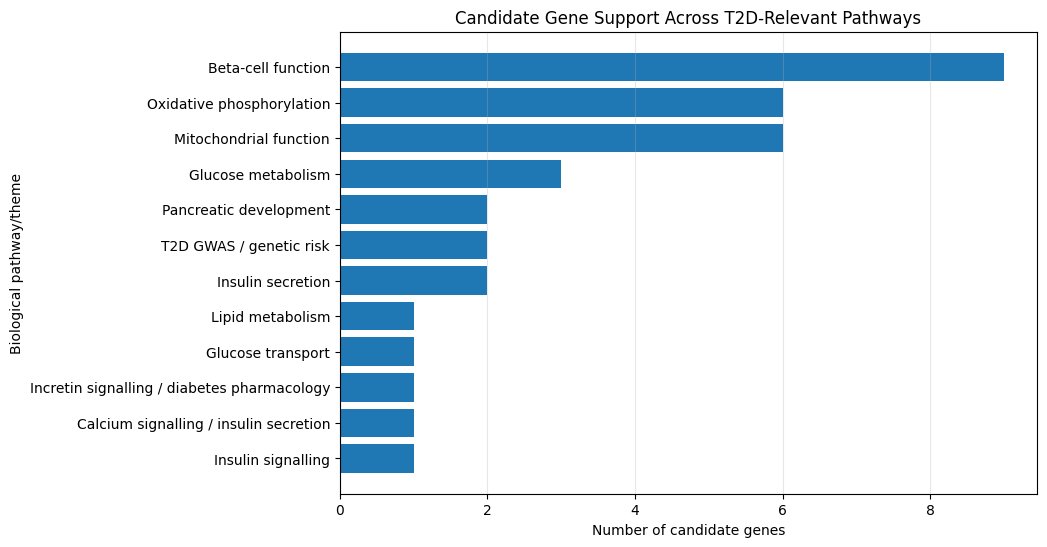

Saved: /content/drive/MyDrive/Project_Protein/model/phase15_biological_literature_support/figures/phase15_candidate_gene_pathway_summary_barplot.png


In [12]:
# ============================================================
# FIGURE 1 — PATHWAY SUMMARY BAR PLOT
# ============================================================

plot_df = pathway_summary_df[pathway_summary_df["n_candidate_genes"] > 0].copy()
plot_df = plot_df.sort_values("n_candidate_genes", ascending=True)

plt.figure(figsize=(9, 6))
plt.barh(plot_df["pathway_group"], plot_df["n_candidate_genes"])
plt.xlabel("Number of candidate genes")
plt.ylabel("Biological pathway/theme")
plt.title("Candidate Gene Support Across T2D-Relevant Pathways")
plt.grid(axis="x", alpha=0.3)

out_path = FIGURE_DIR / "phase15_candidate_gene_pathway_summary_barplot.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

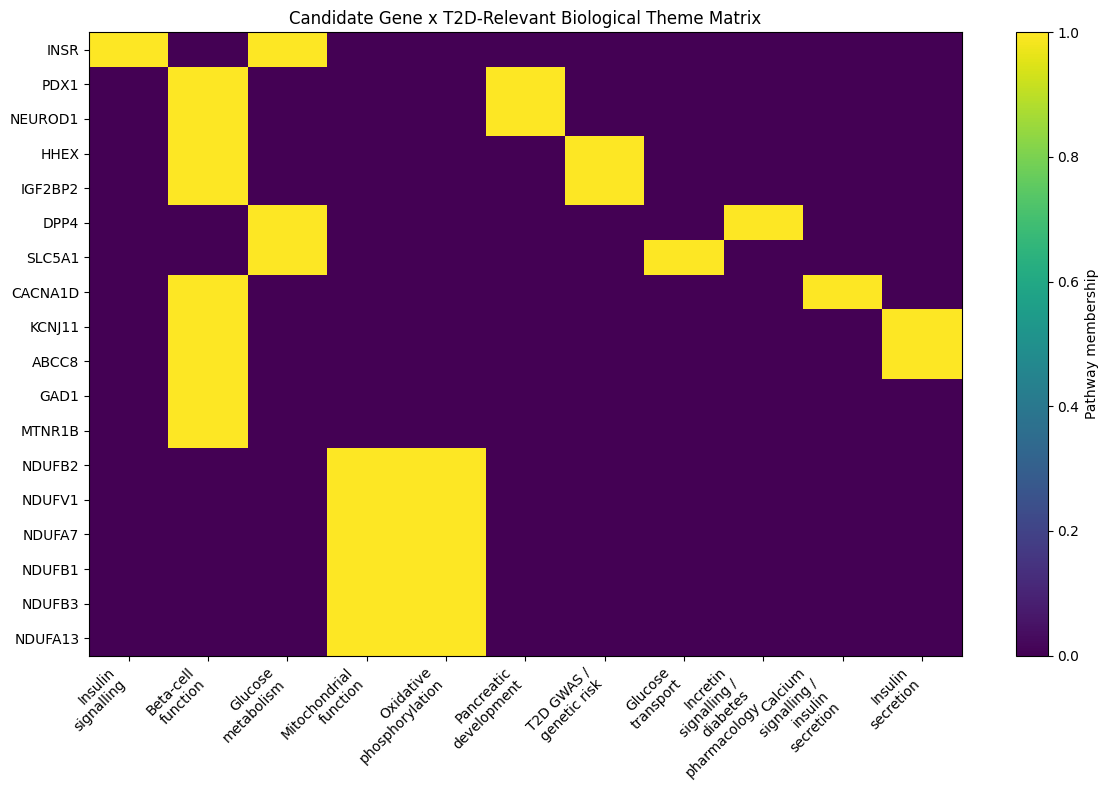

Saved: /content/drive/MyDrive/Project_Protein/model/phase15_biological_literature_support/figures/phase15_candidate_gene_pathway_heatmap.png


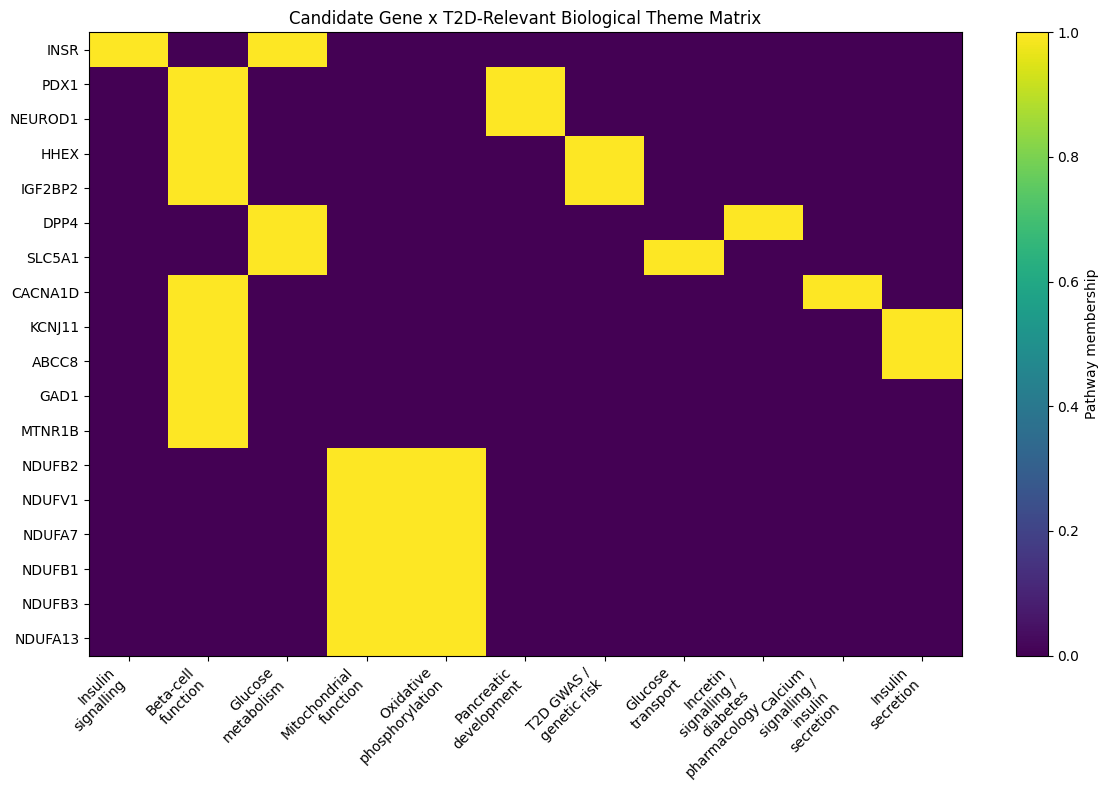

Saved: /content/drive/MyDrive/Project_Protein/model/phase15_biological_literature_support/figures/fig6_candidate_gene_pathway_heatmap.png
Genes shown in heatmap:
['INSR', 'PDX1', 'NEUROD1', 'HHEX', 'IGF2BP2', 'DPP4', 'SLC5A1', 'CACNA1D', 'KCNJ11', 'ABCC8', 'GAD1', 'MTNR1B', 'NDUFB2', 'NDUFV1', 'NDUFA7', 'NDUFB1', 'NDUFB3', 'NDUFA13']

Excluded genes:
['SCD5']


In [13]:
# ============================================================
# FIGURE 2 — CANDIDATE GENE x PATHWAY HEATMAP
# Updated: remove SCD5 due to weaker T2D-specific support
# ============================================================

# Genes to exclude from main biological theme heatmap
EXCLUDE_FROM_MAIN_HEATMAP = ["SCD5"]

# Create filtered pathway matrix
plot_pathway_matrix_df = pathway_matrix_df.copy()

plot_pathway_matrix_df["gene"] = plot_pathway_matrix_df["gene"].astype(str).str.upper()

plot_pathway_matrix_df = plot_pathway_matrix_df[
    ~plot_pathway_matrix_df["gene"].isin(EXCLUDE_FROM_MAIN_HEATMAP)
].copy()

# Build heatmap matrix
heatmap_df = plot_pathway_matrix_df.set_index("gene")[pathway_groups].copy()

# Keep only columns with at least 1 gene
heatmap_df = heatmap_df.loc[:, heatmap_df.sum(axis=0) > 0]

plt.figure(figsize=(12, 8))
plt.imshow(heatmap_df.values, aspect="auto")

plt.xticks(
    np.arange(heatmap_df.shape[1]),
    [wrap_label(c, 16) for c in heatmap_df.columns],
    rotation=45,
    ha="right"
)

plt.yticks(np.arange(heatmap_df.shape[0]), heatmap_df.index)

plt.colorbar(label="Pathway membership")
plt.title("Candidate Gene x T2D-Relevant Biological Theme Matrix")
plt.tight_layout()

# Save original Phase 15 filename
out_path = FIGURE_DIR / "phase15_candidate_gene_pathway_heatmap.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

# Optional: also save using manuscript figure name if Overleaf expects this
out_path2 = FIGURE_DIR / "fig6_candidate_gene_pathway_heatmap.png"
plt.figure(figsize=(12, 8))
plt.imshow(heatmap_df.values, aspect="auto")

plt.xticks(
    np.arange(heatmap_df.shape[1]),
    [wrap_label(c, 16) for c in heatmap_df.columns],
    rotation=45,
    ha="right"
)

plt.yticks(np.arange(heatmap_df.shape[0]), heatmap_df.index)
plt.colorbar(label="Pathway membership")
plt.title("Candidate Gene x T2D-Relevant Biological Theme Matrix")
plt.tight_layout()

plt.savefig(out_path2, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path2)

# Quick check
print("Genes shown in heatmap:")
print(list(heatmap_df.index))

print("\nExcluded genes:")
print(EXCLUDE_FROM_MAIN_HEATMAP)

,gene,Protein_only,Handcrafted_multimodal,DNABERT2_multimodal,Genomic_only,Unknown_model,n_project_files_with_gene
0,INSR,1,1,1,0,0,94
1,PDX1,1,1,1,0,0,79
2,NEUROD1,1,1,1,0,0,80
3,HHEX,1,1,1,0,0,79
4,IGF2BP2,1,1,1,0,0,83
5,DPP4,1,1,1,0,0,84
6,SLC5A1,1,1,1,0,0,89
7,CACNA1D,1,1,1,0,0,83
8,KCNJ11,1,1,1,0,0,65
9,ABCC8,1,1,1,0,0,63


Saved: /content/drive/MyDrive/Project_Protein/model/phase15_biological_literature_support/results/phase15_candidate_gene_model_support_matrix.csv


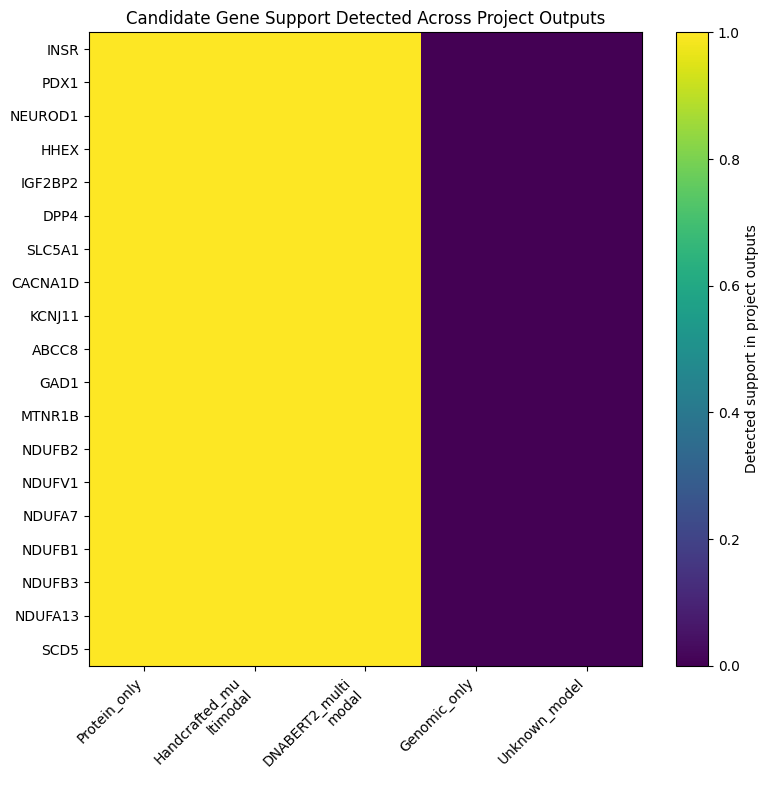

Saved: /content/drive/MyDrive/Project_Protein/model/phase15_biological_literature_support/figures/phase15_candidate_gene_model_support_heatmap.png


In [14]:
# ============================================================
# FIGURE 3 — MODEL/PROJECT SUPPORT HEATMAP
# ============================================================

# Build binary model/source support from detected files
support_models = ["Protein_only", "Handcrafted_multimodal", "DNABERT2_multimodal", "Genomic_only", "Unknown_model"]

support_matrix = []

for gene in candidate_gene_df["gene"]:
    rec = {"gene": gene}
    gene_hits = model_support_hits_df[model_support_hits_df["gene"] == gene] if not model_support_hits_df.empty else pd.DataFrame()

    for model in support_models:
        rec[model] = int((not gene_hits.empty) and (model in set(gene_hits["model_guess"].astype(str))))

    rec["n_project_files_with_gene"] = int(candidate_support_df.loc[candidate_support_df["gene"] == gene, "n_project_files_with_gene"].values[0])
    support_matrix.append(rec)

model_support_matrix_df = pd.DataFrame(support_matrix)

display(model_support_matrix_df)

save_df(model_support_matrix_df, RESULT_DIR / "phase15_candidate_gene_model_support_matrix.csv")

heatmap_model_df = model_support_matrix_df.set_index("gene")[support_models].copy()

plt.figure(figsize=(8, 8))
plt.imshow(heatmap_model_df.values, aspect="auto")

plt.xticks(
    np.arange(heatmap_model_df.shape[1]),
    [wrap_label(c, 14) for c in heatmap_model_df.columns],
    rotation=45,
    ha="right"
)
plt.yticks(np.arange(heatmap_model_df.shape[0]), heatmap_model_df.index)

plt.colorbar(label="Detected support in project outputs")
plt.title("Candidate Gene Support Detected Across Project Outputs")
plt.tight_layout()

out_path = FIGURE_DIR / "phase15_candidate_gene_model_support_heatmap.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)

In [15]:
# ============================================================
# COMPACT MANUSCRIPT TABLE
# ============================================================
# This table can be used in the paper.
# Keep it compact; detailed PubMed results can go to supplementary.
# ============================================================

compact_cols = [
    "gene",
    "pathway_primary",
    "pathway_secondary",
    "mechanistic_role",
    "why_relevant_to_T2D",
    "support_strength",
    "claim_type",
    "suggested_citation_key",
    "n_project_files_with_gene",
    "n_pubmed_records"
]

manuscript_gene_table_df = final_evidence_df[compact_cols].copy()

# Shorten long columns if needed
manuscript_gene_table_df["mechanistic_role_short"] = manuscript_gene_table_df["mechanistic_role"].apply(
    lambda x: x if len(str(x)) <= 120 else str(x)[:117] + "..."
)

manuscript_gene_table_df["interpretation_short"] = manuscript_gene_table_df["why_relevant_to_T2D"].apply(
    lambda x: x if len(str(x)) <= 120 else str(x)[:117] + "..."
)

display(manuscript_gene_table_df)

save_df(
    manuscript_gene_table_df,
    RESULT_DIR / "phase15_manuscript_candidate_gene_literature_table.csv"
)

,gene,pathway_primary,pathway_secondary,mechanistic_role,why_relevant_to_T2D,support_strength,claim_type,suggested_citation_key,n_project_files_with_gene,n_pubmed_records,mechanistic_role_short,interpretation_short
0,INSR,Insulin signalling,Glucose metabolism,Insulin receptor; central mediator of insulin signalling and glucose homeostasis.,Supports the insulin-signalling component of T2D biology.,strong,known mechanism / diabetes gene,"odawara1989insr, ncbi_insr",94,13,Insulin receptor; central mediator of insulin signalling and glucose homeostasis.,Supports the insulin-signalling component of T2D biology.
1,DPP4,Glucose metabolism,Incretin signalling / diabetes pharmacology,Dipeptidyl peptidase-4; regulates incretin hormones and is an established diabetes drug target.,Supports glucose regulation and pharmacological relevance.,strong,diabetes drug target / glucose regulation,deacon2019dpp4,84,13,Dipeptidyl peptidase-4; regulates incretin hormones and is an established diabetes drug target.,Supports glucose regulation and pharmacological relevance.
2,NEUROD1,Beta-cell function,Pancreatic development,Beta-cell transcription factor involved in endocrine pancreas development and insulin regulation.,Supports beta-cell differentiation/function interpretation.,strong,beta-cell transcription factor,"naya1997neurod1, malecki1999neurod1",80,14,Beta-cell transcription factor involved in endocrine pancreas development and insulin regulation.,Supports beta-cell differentiation/function interpretation.
3,PDX1,Beta-cell function,Pancreatic development,Pancreatic transcription factor involved in beta-cell development and insulin gene regulation.,Supports pancreatic beta-cell development and insulin secretion biology.,strong,beta-cell transcription factor,"stoffers1997pdx1, huang2021beta_cell_review",79,11,Pancreatic transcription factor involved in beta-cell development and insulin gene regulation.,Supports pancreatic beta-cell development and insulin secretion biology.
4,MTNR1B,Beta-cell function,T2D GWAS / insulin secretion,Melatonin receptor locus associated with fasting glucose and T2D risk.,Supports genetic-risk and insulin secretion interpretation.,strong,T2D genetic association,lyssenko2009mtnr1b,66,13,Melatonin receptor locus associated with fasting glucose and T2D risk.,Supports genetic-risk and insulin secretion interpretation.
5,KCNJ11,Beta-cell function,Insulin secretion,KATP channel subunit involved in glucose-stimulated insulin secretion.,Supports beta-cell ion-channel and insulin secretion biology.,strong,diabetes gene / insulin secretion,gloyn2004kcnj11,65,15,KATP channel subunit involved in glucose-stimulated insulin secretion.,Supports beta-cell ion-channel and insulin secretion biology.
6,ABCC8,Beta-cell function,Insulin secretion,KATP channel regulatory subunit; involved in insulin secretion and monogenic diabetes/hyperinsulinism.,Supports beta-cell ion-channel and insulin secretion biology.,strong,diabetes gene / insulin secretion,ashcroft2006katp,63,14,KATP channel regulatory subunit; involved in insulin secretion and monogenic diabetes/hyperinsulinism.,Supports beta-cell ion-channel and insulin secretion biology.
7,IGF2BP2,Beta-cell function,T2D GWAS / genetic risk,RNA-binding protein; human variants are associated with increased T2D risk and beta-cell biology.,Supports genetic-risk and beta-cell regulation interpretation.,moderate_to_strong,T2D genetic association,"sladek2007gwas, regue2021igf2bp2",83,14,RNA-binding protein; human variants are associated with increased T2D risk and beta-cell biology.,Supports genetic-risk and beta-cell regulation interpretation.
8,HHEX,Beta-cell function,T2D GWAS / genetic risk,T2D-associated locus implicated in beta-cell function and insulin secretion biology.,Supports genetic-risk and beta-cell interpretation.,moderate_to_strong,T2D genetic association,"sladek2007gwas, florez2008beta_cell_loci",79,14,T2D-associated locus implicated in beta-cell function and insulin secretion biology.

Saved: /content/drive/MyDrive/Project_Protein/model/phase15_biological_literature_support/results/phase15_manuscript_candidate_gene_literature_table.csv


In [16]:
# ============================================================
# MANUSCRIPT-READY BIOLOGICAL PARAGRAPHS
# ============================================================

def genes_for_pathway(pathway):
    if pathway not in pathway_matrix_df.columns:
        return []
    return pathway_matrix_df.loc[pathway_matrix_df[pathway] == 1, "gene"].tolist()

insulin_genes = genes_for_pathway("Insulin signalling")
beta_genes = genes_for_pathway("Beta-cell function")
glucose_genes = genes_for_pathway("Glucose metabolism")
mito_genes = genes_for_pathway("Mitochondrial function")
oxphos_genes = genes_for_pathway("Oxidative phosphorylation")

methods_text = """
To strengthen biological validation, candidate genes from the top-ranked and biologically relevant model outputs were organized into curated T2D-related pathway groups. The pathway groups included insulin signalling, pancreatic beta-cell function, glucose metabolism, mitochondrial function and oxidative phosphorylation. For each selected candidate gene, literature support was manually curated using gene-specific and pathway-level evidence. PubMed-assisted searches were also performed to collect supporting articles for each gene and pathway. The resulting evidence table was used to distinguish strongly supported known T2D candidates from pathway-level and hypothesis-generating candidates.
""".strip()

results_text = f"""
The literature-supported biological validation grouped the main candidate genes into several T2D-relevant mechanisms. Insulin signalling was represented by genes such as {', '.join(insulin_genes) if insulin_genes else 'INSR'}, supporting the relevance of insulin receptor-mediated signalling. Beta-cell function and insulin secretion were represented by candidates including {', '.join(beta_genes[:8])}, consistent with the importance of pancreatic beta-cell dysfunction in T2D. Glucose metabolism and transport were represented by {', '.join(glucose_genes)}, including candidates linked to incretin regulation and glucose transport. The mitochondrial/OXPHOS theme was represented by {', '.join(mito_genes[:8])}, most of which encode mitochondrial complex I-related proteins. These mitochondrial candidates support the pathway-level interpretation that oxidative phosphorylation and mitochondrial function may contribute to the biological signal captured by the model rankings.
""".strip()

discussion_text = """
The expanded literature support strengthens the biological interpretation of the top-ranked candidate genes. Genes such as INSR, PDX1, NEUROD1, IGF2BP2, HHEX, DPP4, KCNJ11 and MTNR1B have stronger prior links to T2D, insulin secretion, beta-cell function, glucose regulation or diabetes pharmacology. In contrast, the NDUF-family genes should be interpreted primarily at the pathway level rather than as individually validated T2D causal genes. Their importance lies in their collective representation of mitochondrial complex I and oxidative phosphorylation biology, which is consistent with established evidence that mitochondrial dysfunction contributes to beta-cell failure in T2D. Therefore, the biological validation supports a cautious but coherent interpretation: the model rankings recover known T2D biology and also highlight mitochondrial/OXPHOS candidates as hypothesis-generating targets for further validation.
""".strip()

biological_wording_df = pd.DataFrame([
    {"section": "Methods - Biological Literature Support", "text": methods_text},
    {"section": "Results - Literature-Supported Biological Validation", "text": results_text},
    {"section": "Discussion - Biological Interpretation", "text": discussion_text}
])

display(biological_wording_df)

save_df(
    biological_wording_df,
    RESULT_DIR / "phase15_manuscript_ready_biological_wording.csv"
)

with open(REPORT_DIR / "phase15_manuscript_ready_biological_wording.md", "w") as f:
    for _, row in biological_wording_df.iterrows():
        f.write(f"## {row['section']}\n\n")
        f.write(row["text"] + "\n\n")

print("Saved manuscript wording.")

,section,text
0,Methods - Biological Literature Support,"To strengthen biological validation, candidate genes from the top-ranked and biologically relevant model outputs were organized into curated T2D-related pathway groups. The pathway groups included insulin signalling, pancreatic beta-cell function, glucose metabolism, mitochondrial function and oxidative phosphorylation. For each selected candidate gene, literature support was manually curated using gene-specific and pathway-level evidence. PubMed-assisted searches were also performed to coll..."
1,Results - Literature-Supported Biological Validation,"The literature-supported biological validation grouped the main candidate genes into several T2D-relevant mechanisms. Insulin signalling was represented by genes such as INSR, supporting the relevance of insulin receptor-mediated signalling. Beta-cell function and insulin secretion were represented by candidates including PDX1, NEUROD1, HHEX, IGF2BP2, CACNA1D, KCNJ11, ABCC8, GAD1, consistent with the importance of pancreatic beta-cell dysfunction in T2D. Glucose metabolism and transport were..."
2,Discussion - Biological Interpretation,"The expanded literature support strengthens the biological interpretation of the top-ranked candidate genes. Genes such as INSR, PDX1, NEUROD1, IGF2BP2, HHEX, DPP4, KCNJ11 and MTNR1B have stronger prior links to T2D, insulin secretion, beta-cell function, glucose regulation or diabetes pharmacology. In contrast, the NDUF-family genes should be interpreted primarily at the pathway level rather than as individually validated T2D causal genes. Their importance lies in their collective represent..."


Saved: /content/drive/MyDrive/Project_Protein/model/phase15_biological_literature_support/results/phase15_manuscript_ready_biological_wording.csv
Saved manuscript wording.


In [17]:
# ============================================================
# BIBTEX STARTER ENTRIES
# ============================================================
# These are starter BibTeX entries. You should verify metadata before final submission.
# For first revision draft, they help organize references.
# ============================================================

bibtex_entries = r"""
@article{deacon2019dpp4,
  author  = {Deacon, Carolyn F.},
  title   = {Physiology and Pharmacology of DPP-4 in Glucose Homeostasis and the Treatment of Type 2 Diabetes},
  journal = {Frontiers in Endocrinology},
  year    = {2019},
  volume  = {10},
  pages   = {80},
  doi     = {10.3389/fendo.2019.00080}
}

@article{regue2021igf2bp2,
  author  = {Regu{\'e}, Laura and others},
  title   = {RNA m6A Reader IMP2/IGF2BP2 Promotes Pancreatic Beta-Cell Proliferation and Insulin Secretion},
  journal = {Molecular Metabolism},
  year    = {2021},
  volume  = {48},
  pages   = {101209},
  doi     = {10.1016/j.molmet.2021.101209}
}

@article{ma2011mitochondrial_beta_cell,
  author  = {Ma, Zuheng A. and Zhao, Zhongmin and Turk, John},
  title   = {Mitochondrial Dysfunction and Beta-Cell Failure in Type 2 Diabetes Mellitus},
  journal = {Experimental Diabetes Research},
  year    = {2012},
  volume  = {2012},
  pages   = {703538},
  doi     = {10.1155/2012/703538}
}

@article{florez2008beta_cell_loci,
  author  = {Florez, Jose C.},
  title   = {Newly Identified Loci Highlight Beta Cell Dysfunction as a Key Cause of Type 2 Diabetes: Where Are the Insulin Resistance Genes?},
  journal = {Diabetologia},
  year    = {2008},
  volume  = {51},
  pages   = {1100--1110},
  doi     = {10.1007/s00125-008-1025-9}
}

@article{sladek2007gwas,
  author  = {Sladek, Robert and Rocheleau, Ghislain and Rung, Johan and Dina, Christian and Shen, Lishuang and Serre, David and Boutin, Philippe and Vincent, Daniel and Belisle, Alexandre and Hadjadj, Samy and others},
  title   = {A Genome-Wide Association Study Identifies Novel Risk Loci for Type 2 Diabetes},
  journal = {Nature},
  year    = {2007},
  volume  = {445},
  pages   = {881--885},
  doi     = {10.1038/nature05616}
}

@article{lyssenko2009mtnr1b,
  author  = {Lyssenko, Valeriya and Nagorny, Cecilia L. F. and Erdos, Michael R. and Wierup, Nils and Jonsson, Anna and Sp{\'e}gel, Peter and Bugliani, Marco and Saxena, Richa and Fex, Malin and Pulizzi, Nicole and others},
  title   = {Common Variant in MTNR1B Associated with Increased Risk of Type 2 Diabetes and Impaired Early Insulin Secretion},
  journal = {Nature Genetics},
  year    = {2009},
  volume  = {41},
  pages   = {82--88},
  doi     = {10.1038/ng.288}
}

@article{gloyn2004kcnj11,
  author  = {Gloyn, Anna L. and Weedon, Michael N. and Owen, Katharine R. and Turner, Mark J. and Knight, Bridget A. and Hitman, Graham and Walker, Mark and Levy, Jonathan C. and Sampson, Michael and Halford, Sarah and others},
  title   = {Large-Scale Association Studies of Variants in Genes Encoding the Pancreatic Beta-Cell KATP Channel Subunits Kir6.2 and SUR1 Confirm that the KCNJ11 E23K Variant is Associated with Type 2 Diabetes},
  journal = {Diabetes},
  year    = {2003},
  volume  = {52},
  pages   = {568--572},
  doi     = {10.2337/diabetes.52.2.568}
}

@article{hong2014ndufv1,
  author  = {Hong, Ja Young and others},
  title   = {Mitochondrial Complex I Deficiency Enhances Skeletal Myogenesis but Impairs Insulin Signaling through SIRT1 Inactivation},
  journal = {Journal of Biological Chemistry},
  year    = {2014},
  volume  = {289},
  number  = {29},
  pages   = {20012--20025},
  doi     = {10.1074/jbc.M114.558080}
}
""".strip()

bibtex_path = REPORT_DIR / "phase15_bibtex_starter_entries.bib"
with open(bibtex_path, "w") as f:
    f.write(bibtex_entries)

print("Saved BibTeX starter entries:", bibtex_path)

Saved BibTeX starter entries: /content/drive/MyDrive/Project_Protein/model/phase15_biological_literature_support/reports/phase15_bibtex_starter_entries.bib


In [18]:
# ============================================================
# EXPORT EXCEL WORKBOOK
# ============================================================

excel_path = EXCEL_DIR / "phase15_biological_literature_support_tables.xlsx"

tables = {
    "Candidate_Framework": candidate_gene_df,
    "Literature_Seed": literature_seed_df,
    "PubMed_Results": pubmed_results_df,
    "Model_Support_Hits": model_support_hits_df,
    "Support_Summary": candidate_support_df,
    "Pathway_Matrix": pathway_matrix_df,
    "Pathway_Summary": pathway_summary_df,
    "Model_Support_Matrix": model_support_matrix_df,
    "Final_Evidence_Table": final_evidence_df,
    "Manuscript_Gene_Table": manuscript_gene_table_df,
    "Manuscript_Wording": biological_wording_df
}

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    for sheet_name, df in tables.items():
        if df is not None and not df.empty:
            df.to_excel(writer, sheet_name=sheet_name[:31], index=False)

print("Saved Excel:", excel_path)

Saved Excel: /content/drive/MyDrive/Project_Protein/model/phase15_biological_literature_support/excel/phase15_biological_literature_support_tables.xlsx


In [19]:
# ============================================================
# FINAL SUMMARY
# ============================================================

print("=== PHASE 15 COMPLETE ===")

print("\nCandidate genes:")
display(candidate_gene_df[["gene", "pathway_primary", "pathway_secondary", "support_strength"]])

print("\nPathway summary:")
display(pathway_summary_df)

print("\nFinal evidence table:")
display(final_evidence_df[[
    "gene",
    "pathway_primary",
    "pathway_secondary",
    "support_strength",
    "claim_type",
    "n_project_files_with_gene",
    "n_pubmed_records",
    "suggested_citation_key"
]].head(30))

print("\nManuscript table:")
display(manuscript_gene_table_df.head(30))

print("\nFigures:")
for p in sorted(FIGURE_DIR.glob("*")):
    print(p)

print("\nResults:")
for p in sorted(RESULT_DIR.glob("*")):
    print(p)

print("\nReports:")
for p in sorted(REPORT_DIR.glob("*")):
    print(p)

print("\nExcel:")
for p in sorted(EXCEL_DIR.glob("*")):
    print(p)

=== PHASE 15 COMPLETE ===

Candidate genes:


,gene,pathway_primary,pathway_secondary,support_strength
0,INSR,Insulin signalling,Glucose metabolism,strong
1,PDX1,Beta-cell function,Pancreatic development,strong
2,NEUROD1,Beta-cell function,Pancreatic development,strong
3,HHEX,Beta-cell function,T2D GWAS / genetic risk,moderate_to_strong
4,IGF2BP2,Beta-cell function,T2D GWAS / genetic risk,moderate_to_strong
5,DPP4,Glucose metabolism,Incretin signalling / diabetes pharmacology,strong
6,SLC5A1,Glucose metabolism,Glucose transport,moderate
7,CACNA1D,Beta-cell function,Calcium signalling / insulin secretion,moderate
8,KCNJ11,Beta-cell function,Insulin secretion,strong
9,ABCC8,Beta-cell function,Insulin secretion,strong



Pathway summary:


,pathway_group,n_candidate_genes,genes
0,Beta-cell function,9,PDX1; NEUROD1; HHEX; IGF2BP2; CACNA1D; KCNJ11; ABCC8; GAD1; MTNR1B
1,Mitochondrial function,6,NDUFB2; NDUFV1; NDUFA7; NDUFB1; NDUFB3; NDUFA13
2,Oxidative phosphorylation,6,NDUFB2; NDUFV1; NDUFA7; NDUFB1; NDUFB3; NDUFA13
3,Glucose metabolism,3,INSR; DPP4; SLC5A1
4,T2D GWAS / genetic risk,2,HHEX; IGF2BP2
5,Pancreatic development,2,PDX1; NEUROD1
6,Insulin secretion,2,KCNJ11; ABCC8
7,Insulin signalling,1,INSR
8,Glucose transport,1,SLC5A1
9,Incretin signalling / diabetes pharmacology,1,DPP4



Final evidence table:


,gene,pathway_primary,pathway_secondary,support_strength,claim_type,n_project_files_with_gene,n_pubmed_records,suggested_citation_key
0,INSR,Insulin signalling,Glucose metabolism,strong,known mechanism / diabetes gene,94,13,"odawara1989insr, ncbi_insr"
1,DPP4,Glucose metabolism,Incretin signalling / diabetes pharmacology,strong,diabetes drug target / glucose regulation,84,13,deacon2019dpp4
2,NEUROD1,Beta-cell function,Pancreatic development,strong,beta-cell transcription factor,80,14,"naya1997neurod1, malecki1999neurod1"
3,PDX1,Beta-cell function,Pancreatic development,strong,beta-cell transcription factor,79,11,"stoffers1997pdx1, huang2021beta_cell_review"
4,MTNR1B,Beta-cell function,T2D GWAS / insulin secretion,strong,T2D genetic association,66,13,lyssenko2009mtnr1b
5,KCNJ11,Beta-cell function,Insulin secretion,strong,diabetes gene / insulin secretion,65,15,gloyn2004kcnj11
6,ABCC8,Beta-cell function,Insulin secretion,strong,diabetes gene / insulin secretion,63,14,ashcroft2006katp
7,IGF2BP2,Beta-cell function,T2D GWAS / genetic risk,moderate_to_strong,T2D genetic association,83,14,"sladek2007gwas, regue2021igf2bp2"
8,HHEX,Beta-cell function,T2D GWAS / genetic risk,moderate_to_strong,T2D genetic association,79,14,"sladek2007gwas, florez2008beta_cell_loci"
9,SLC5A1,Glucose metabolism,Glucose transport,moderate,glucose transport biology,89,10,wright2011sglt



Manuscript table:


,gene,pathway_primary,pathway_secondary,mechanistic_role,why_relevant_to_T2D,support_strength,claim_type,suggested_citation_key,n_project_files_with_gene,n_pubmed_records,mechanistic_role_short,interpretation_short
0,INSR,Insulin signalling,Glucose metabolism,Insulin receptor; central mediator of insulin signalling and glucose homeostasis.,Supports the insulin-signalling component of T2D biology.,strong,known mechanism / diabetes gene,"odawara1989insr, ncbi_insr",94,13,Insulin receptor; central mediator of insulin signalling and glucose homeostasis.,Supports the insulin-signalling component of T2D biology.
1,DPP4,Glucose metabolism,Incretin signalling / diabetes pharmacology,Dipeptidyl peptidase-4; regulates incretin hormones and is an established diabetes drug target.,Supports glucose regulation and pharmacological relevance.,strong,diabetes drug target / glucose regulation,deacon2019dpp4,84,13,Dipeptidyl peptidase-4; regulates incretin hormones and is an established diabetes drug target.,Supports glucose regulation and pharmacological relevance.
2,NEUROD1,Beta-cell function,Pancreatic development,Beta-cell transcription factor involved in endocrine pancreas development and insulin regulation.,Supports beta-cell differentiation/function interpretation.,strong,beta-cell transcription factor,"naya1997neurod1, malecki1999neurod1",80,14,Beta-cell transcription factor involved in endocrine pancreas development and insulin regulation.,Supports beta-cell differentiation/function interpretation.
3,PDX1,Beta-cell function,Pancreatic development,Pancreatic transcription factor involved in beta-cell development and insulin gene regulation.,Supports pancreatic beta-cell development and insulin secretion biology.,strong,beta-cell transcription factor,"stoffers1997pdx1, huang2021beta_cell_review",79,11,Pancreatic transcription factor involved in beta-cell development and insulin gene regulation.,Supports pancreatic beta-cell development and insulin secretion biology.
4,MTNR1B,Beta-cell function,T2D GWAS / insulin secretion,Melatonin receptor locus associated with fasting glucose and T2D risk.,Supports genetic-risk and insulin secretion interpretation.,strong,T2D genetic association,lyssenko2009mtnr1b,66,13,Melatonin receptor locus associated with fasting glucose and T2D risk.,Supports genetic-risk and insulin secretion interpretation.
5,KCNJ11,Beta-cell function,Insulin secretion,KATP channel subunit involved in glucose-stimulated insulin secretion.,Supports beta-cell ion-channel and insulin secretion biology.,strong,diabetes gene / insulin secretion,gloyn2004kcnj11,65,15,KATP channel subunit involved in glucose-stimulated insulin secretion.,Supports beta-cell ion-channel and insulin secretion biology.
6,ABCC8,Beta-cell function,Insulin secretion,KATP channel regulatory subunit; involved in insulin secretion and monogenic diabetes/hyperinsulinism.,Supports beta-cell ion-channel and insulin secretion biology.,strong,diabetes gene / insulin secretion,ashcroft2006katp,63,14,KATP channel regulatory subunit; involved in insulin secretion and monogenic diabetes/hyperinsulinism.,Supports beta-cell ion-channel and insulin secretion biology.
7,IGF2BP2,Beta-cell function,T2D GWAS / genetic risk,RNA-binding protein; human variants are associated with increased T2D risk and beta-cell biology.,Supports genetic-risk and beta-cell regulation interpretation.,moderate_to_strong,T2D genetic association,"sladek2007gwas, regue2021igf2bp2",83,14,RNA-binding protein; human variants are associated with increased T2D risk and beta-cell biology.,Supports genetic-risk and beta-cell regulation interpretation.
8,HHEX,Beta-cell function,T2D GWAS / genetic risk,T2D-associated locus implicated in beta-cell function and insulin secretion biology.,Supports genetic-risk and beta-cell interpretation.,moderate_to_strong,T2D genetic association,"sladek2007gwas, florez2008beta_cell_loci",79,14,T2D-associated locus implicated in beta-cell function and insulin secretion biology.


Figures:
/content/drive/MyDrive/Project_Protein/model/phase15_biological_literature_support/figures/fig6_candidate_gene_pathway_heatmap.png
/content/drive/MyDrive/Project_Protein/model/phase15_biological_literature_support/figures/phase15_candidate_gene_model_support_heatmap.png
/content/drive/MyDrive/Project_Protein/model/phase15_biological_literature_support/figures/phase15_candidate_gene_pathway_heatmap.png
/content/drive/MyDrive/Project_Protein/model/phase15_biological_literature_support/figures/phase15_candidate_gene_pathway_summary_barplot.png

Results:
/content/drive/MyDrive/Project_Protein/model/phase15_biological_literature_support/results/phase15_candidate_gene_model_support_hits.csv
/content/drive/MyDrive/Project_Protein/model/phase15_biological_literature_support/results/phase15_candidate_gene_model_support_matrix.csv
/content/drive/MyDrive/Project_Protein/model/phase15_biological_literature_support/results/phase15_candidate_gene_pathway_matrix.csv
/content/drive/MyDrive/P

In [20]:
display(pathway_summary_df)
display(final_evidence_df[[
    "gene",
    "pathway_primary",
    "pathway_secondary",
    "mechanistic_role",
    "support_strength",
    "claim_type",
    "n_project_files_with_gene",
    "n_pubmed_records",
    "suggested_citation_key"
]])

display(manuscript_gene_table_df)

display(biological_wording_df)

if not pubmed_results_df.empty:
    display(pubmed_results_df.head(50))

,pathway_group,n_candidate_genes,genes
0,Beta-cell function,9,PDX1; NEUROD1; HHEX; IGF2BP2; CACNA1D; KCNJ11; ABCC8; GAD1; MTNR1B
1,Mitochondrial function,6,NDUFB2; NDUFV1; NDUFA7; NDUFB1; NDUFB3; NDUFA13
2,Oxidative phosphorylation,6,NDUFB2; NDUFV1; NDUFA7; NDUFB1; NDUFB3; NDUFA13
3,Glucose metabolism,3,INSR; DPP4; SLC5A1
4,T2D GWAS / genetic risk,2,HHEX; IGF2BP2
5,Pancreatic development,2,PDX1; NEUROD1
6,Insulin secretion,2,KCNJ11; ABCC8
7,Insulin signalling,1,INSR
8,Glucose transport,1,SLC5A1
9,Incretin signalling / diabetes pharmacology,1,DPP4


,gene,pathway_primary,pathway_secondary,mechanistic_role,support_strength,claim_type,n_project_files_with_gene,n_pubmed_records,suggested_citation_key
0,INSR,Insulin signalling,Glucose metabolism,Insulin receptor; central mediator of insulin signalling and glucose homeostasis.,strong,known mechanism / diabetes gene,94,13,"odawara1989insr, ncbi_insr"
1,DPP4,Glucose metabolism,Incretin signalling / diabetes pharmacology,Dipeptidyl peptidase-4; regulates incretin hormones and is an established diabetes drug target.,strong,diabetes drug target / glucose regulation,84,13,deacon2019dpp4
2,NEUROD1,Beta-cell function,Pancreatic development,Beta-cell transcription factor involved in endocrine pancreas development and insulin regulation.,strong,beta-cell transcription factor,80,14,"naya1997neurod1, malecki1999neurod1"
3,PDX1,Beta-cell function,Pancreatic development,Pancreatic transcription factor involved in beta-cell development and insulin gene regulation.,strong,beta-cell transcription factor,79,11,"stoffers1997pdx1, huang2021beta_cell_review"
4,MTNR1B,Beta-cell function,T2D GWAS / insulin secretion,Melatonin receptor locus associated with fasting glucose and T2D risk.,strong,T2D genetic association,66,13,lyssenko2009mtnr1b
5,KCNJ11,Beta-cell function,Insulin secretion,KATP channel subunit involved in glucose-stimulated insulin secretion.,strong,diabetes gene / insulin secretion,65,15,gloyn2004kcnj11
6,ABCC8,Beta-cell function,Insulin secretion,KATP channel regulatory subunit; involved in insulin secretion and monogenic diabetes/hyperinsulinism.,strong,diabetes gene / insulin secretion,63,14,ashcroft2006katp
7,IGF2BP2,Beta-cell function,T2D GWAS / genetic risk,RNA-binding protein; human variants are associated with increased T2D risk and beta-cell biology.,moderate_to_strong,T2D genetic association,83,14,"sladek2007gwas, regue2021igf2bp2"
8,HHEX,Beta-cell function,T2D GWAS / genetic risk,T2D-associated locus implicated in beta-cell function and insulin secretion biology.,moderate_to_strong,T2D genetic association,79,14,"sladek2007gwas, florez2008beta_cell_loci"
9,SLC5A1,Glucose metabolism,Glucose transport,Sodium-glucose cotransporter involved in intestinal glucose absorption.,moderate,glucose transport biology,89,10,wright2011sglt


,gene,pathway_primary,pathway_secondary,mechanistic_role,why_relevant_to_T2D,support_strength,claim_type,suggested_citation_key,n_project_files_with_gene,n_pubmed_records,mechanistic_role_short,interpretation_short
0,INSR,Insulin signalling,Glucose metabolism,Insulin receptor; central mediator of insulin signalling and glucose homeostasis.,Supports the insulin-signalling component of T2D biology.,strong,known mechanism / diabetes gene,"odawara1989insr, ncbi_insr",94,13,Insulin receptor; central mediator of insulin signalling and glucose homeostasis.,Supports the insulin-signalling component of T2D biology.
1,DPP4,Glucose metabolism,Incretin signalling / diabetes pharmacology,Dipeptidyl peptidase-4; regulates incretin hormones and is an established diabetes drug target.,Supports glucose regulation and pharmacological relevance.,strong,diabetes drug target / glucose regulation,deacon2019dpp4,84,13,Dipeptidyl peptidase-4; regulates incretin hormones and is an established diabetes drug target.,Supports glucose regulation and pharmacological relevance.
2,NEUROD1,Beta-cell function,Pancreatic development,Beta-cell transcription factor involved in endocrine pancreas development and insulin regulation.,Supports beta-cell differentiation/function interpretation.,strong,beta-cell transcription factor,"naya1997neurod1, malecki1999neurod1",80,14,Beta-cell transcription factor involved in endocrine pancreas development and insulin regulation.,Supports beta-cell differentiation/function interpretation.
3,PDX1,Beta-cell function,Pancreatic development,Pancreatic transcription factor involved in beta-cell development and insulin gene regulation.,Supports pancreatic beta-cell development and insulin secretion biology.,strong,beta-cell transcription factor,"stoffers1997pdx1, huang2021beta_cell_review",79,11,Pancreatic transcription factor involved in beta-cell development and insulin gene regulation.,Supports pancreatic beta-cell development and insulin secretion biology.
4,MTNR1B,Beta-cell function,T2D GWAS / insulin secretion,Melatonin receptor locus associated with fasting glucose and T2D risk.,Supports genetic-risk and insulin secretion interpretation.,strong,T2D genetic association,lyssenko2009mtnr1b,66,13,Melatonin receptor locus associated with fasting glucose and T2D risk.,Supports genetic-risk and insulin secretion interpretation.
5,KCNJ11,Beta-cell function,Insulin secretion,KATP channel subunit involved in glucose-stimulated insulin secretion.,Supports beta-cell ion-channel and insulin secretion biology.,strong,diabetes gene / insulin secretion,gloyn2004kcnj11,65,15,KATP channel subunit involved in glucose-stimulated insulin secretion.,Supports beta-cell ion-channel and insulin secretion biology.
6,ABCC8,Beta-cell function,Insulin secretion,KATP channel regulatory subunit; involved in insulin secretion and monogenic diabetes/hyperinsulinism.,Supports beta-cell ion-channel and insulin secretion biology.,strong,diabetes gene / insulin secretion,ashcroft2006katp,63,14,KATP channel regulatory subunit; involved in insulin secretion and monogenic diabetes/hyperinsulinism.,Supports beta-cell ion-channel and insulin secretion biology.
7,IGF2BP2,Beta-cell function,T2D GWAS / genetic risk,RNA-binding protein; human variants are associated with increased T2D risk and beta-cell biology.,Supports genetic-risk and beta-cell regulation interpretation.,moderate_to_strong,T2D genetic association,"sladek2007gwas, regue2021igf2bp2",83,14,RNA-binding protein; human variants are associated with increased T2D risk and beta-cell biology.,Supports genetic-risk and beta-cell regulation interpretation.
8,HHEX,Beta-cell function,T2D GWAS / genetic risk,T2D-associated locus implicated in beta-cell function and insulin secretion biology.,Supports genetic-risk and beta-cell interpretation.,moderate_to_strong,T2D genetic association,"sladek2007gwas, florez2008beta_cell_loci",79,14,T2D-associated locus implicated in beta-cell function and insulin secretion biology.

,section,text
0,Methods - Biological Literature Support,"To strengthen biological validation, candidate genes from the top-ranked and biologically relevant model outputs were organized into curated T2D-related pathway groups. The pathway groups included insulin signalling, pancreatic beta-cell function, glucose metabolism, mitochondrial function and oxidative phosphorylation. For each selected candidate gene, literature support was manually curated using gene-specific and pathway-level evidence. PubMed-assisted searches were also performed to coll..."
1,Results - Literature-Supported Biological Validation,"The literature-supported biological validation grouped the main candidate genes into several T2D-relevant mechanisms. Insulin signalling was represented by genes such as INSR, supporting the relevance of insulin receptor-mediated signalling. Beta-cell function and insulin secretion were represented by candidates including PDX1, NEUROD1, HHEX, IGF2BP2, CACNA1D, KCNJ11, ABCC8, GAD1, consistent with the importance of pancreatic beta-cell dysfunction in T2D. Glucose metabolism and transport were..."
2,Discussion - Biological Interpretation,"The expanded literature support strengthens the biological interpretation of the top-ranked candidate genes. Genes such as INSR, PDX1, NEUROD1, IGF2BP2, HHEX, DPP4, KCNJ11 and MTNR1B have stronger prior links to T2D, insulin secretion, beta-cell function, glucose regulation or diabetes pharmacology. In contrast, the NDUF-family genes should be interpreted primarily at the pathway level rather than as individually validated T2D causal genes. Their importance lies in their collective represent..."


,gene,pathway_primary,query,result_rank,pmid,title,journal,pubdate,authors,url
0,INSR,Insulin signalling,INSR type 2 diabetes,1,42328113,Genetic Evidence for the Benefits and Risks of Glucose-Lowering Drugs on Cardiovascular-Kidney-Metabolic Syndrome: A Drug-Target Mendelian Randomization Study.,International journal of medical sciences,2026,"Lu J, Sun S, Shang X, Jiang S, Deng Z",https://pubmed.ncbi.nlm.nih.gov/42328113/
1,INSR,Insulin signalling,INSR type 2 diabetes,2,42247987,Microalgae-derived astaxanthin modulates the hormone receptor network associated with type 2 diabetes mellitus: An in-silico investigation supported by experimental literature.,Computational biology and chemistry,2026 Oct,"Sazlı N, Karataş D",https://pubmed.ncbi.nlm.nih.gov/42247987/
2,INSR,Insulin signalling,INSR type 2 diabetes,3,42227366,Target Perturbation of Genetically Proxied Antidiabetic Drug Targets and Pneumonia Risk: A Mendelian Randomization Analysis.,Current topics in medicinal chemistry,2026 May 19,"Lin S, Xu H, Xia J, Xu F",https://pubmed.ncbi.nlm.nih.gov/42227366/
3,INSR,Insulin signalling,INSR type 2 diabetes,4,42216630,Caffeoylquinic Acids From Lonicera japonica Thunb. as Hypoglycemic Agents: Network Pharmacology and Pharmacological Validation.,Journal of diabetes research,2026,"Ye Y, Xu D, Zhang S, Yu H, Liu Y",https://pubmed.ncbi.nlm.nih.gov/42216630/
4,INSR,Insulin signalling,INSR type 2 diabetes,5,42200339,"Causal links between diabetes, gut microbiota, and colon cancer: insights from Mendelian randomization.",Endokrynologia Polska,2026,"Liu T, Tong Q",https://pubmed.ncbi.nlm.nih.gov/42200339/
5,INSR,Insulin signalling,INSR T2D Insulin signalling,1,42216630,Caffeoylquinic Acids From Lonicera japonica Thunb. as Hypoglycemic Agents: Network Pharmacology and Pharmacological Validation.,Journal of diabetes research,2026,"Ye Y, Xu D, Zhang S, Yu H, Liu Y",https://pubmed.ncbi.nlm.nih.gov/42216630/
6,INSR,Insulin signalling,INSR T2D Insulin signalling,2,41970998,Identification of novel genomic variants in diabetic nephropathy patients using whole-exome sequencing: a pilot investigation.,Frontiers in endocrinology,2026,"Mir R, Elfaki I, Almassabi RF, Almowallad S, Elnageeb ME",https://pubmed.ncbi.nlm.nih.gov/41970998/
7,INSR,Insulin signalling,INSR T2D Insulin signalling,3,41556164,Deciphering CD4+ Naive T cell-mediated divergent pathogenic links between type 2 diabetes and pathologic scarring via an integrated multi-omics approach.,"International journal of surgery (London, England)",2026 Jan 19,"Zhu G, Xu J, Guo G, Zhu F",https://pubmed.ncbi.nlm.nih.gov/41556164/
8,INSR,Insulin signalling,INSR T2D Insulin signalling,4,41320781,Butyrate-Mediated Upregulation of Insulin Pathway Gene Expression Suggests Potential Antidiabetic Effects.,Drug development research,2025 Dec,"Shapira E, Voinsky I, Klin H, Gurwitz D",https://pubmed.ncbi.nlm.nih.gov/41320781/
9,INSR,Insulin signalling,INSR T2D Insulin signalling,5,41163347,Is Predisposition to T2D Impacted by Polymorphisms in Genes Involved in Insulin Signaling and Cellular Bioenergetics?,"Acta physiologica (Oxford, England)",2025 Dec,"Pati B, Jastroch M, Bal NC",https://pubmed.ncbi.nlm.nih.gov/41163347/
